# 1-2.Tổng Thu Thập Và Xứ Lý Dữ Liệu

## Mục tiêu
- Lấy dữ liệu tất cả cổ phiếu từ HOSE, HNX và UPCOM trong 3 năm gần nhất (1/1/2022 - 31/12/2024)
- Tính toán các chỉ báo kỹ thuật: RSI, PSAR, Engulfing Pattern
- Tập hợp tất cả dữ liệu vào 1 file CSV


In [1]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
from datetime import datetime, timedelta
import time
import warnings
import os
warnings.filterwarnings('ignore')
from FiinQuantX import FiinSession

# Thiết lập thông tin đăng nhập
username = 'DSTC_17@fiinquant.vn'
password = 'Fiinquant0606'


In [2]:
# Kết nối với FiinQuantX API
try:
    client = FiinSession(username=username, password=password).login()
    print("Đăng nhập thành công!")
    
    # Khám phá các methods có sẵn
    print("\nCác methods có sẵn:")
    methods = [method for method in dir(client) if not method.startswith('_')]
    for method in methods:
        print(f"- {method}")
        
except Exception as e:
    print(f"Lỗi kết nối: {e}")
    print("Vui lòng kiểm tra lại thông tin đăng nhập hoặc kết nối mạng")


Đăng nhập thành công!

Các methods có sẵn:
- BidAsk
- Fetch_Trading_Data
- FiinIndicator
- FindDateCorrelation
- FundamentalAnalysis
- GetDataPoint
- OrderBook
- PriceStatistics
- Rebalance
- SimilarChart
- TickerList
- Trading_Data_Stream
- access_token
- bodyGetToken
- expired_token
- is_login
- login
- password
- urlGetToken
- username


In [3]:
# Lấy danh sách cổ phiếu theo từng sàn với error handling
try:
    hose_data = client.TickerList(ticker="VNINDEX")
    hose_stocks = list(hose_data) if hasattr(hose_data, '__iter__') else [hose_data] if hose_data else []
    
    hnx_data = client.TickerList(ticker="HNXINDEX")
    hnx_stocks = list(hnx_data) if hasattr(hnx_data, '__iter__') else [hnx_data] if hnx_data else []
    
    upcom_data = client.TickerList(ticker="UPCOMINDEX")
    upcom_stocks = list(upcom_data) if hasattr(upcom_data, '__iter__') else [upcom_data] if upcom_data else []
    
    print(f"Tổng số cổ phiếu HOSE (raw): {len(hose_stocks)}")
    print(f"Tổng số cổ phiếu HNX (raw): {len(hnx_stocks)}")
    print(f"Tổng số cổ phiếu UPCOM (raw): {len(upcom_stocks)}")
    
    # Tổng hợp tất cả và loại bỏ trùng lặp
    all_stocks = list(set(hose_stocks + hnx_stocks + upcom_stocks))
    
    # Lọc bỏ các giá trị None hoặc empty
    all_stocks = [stock for stock in all_stocks if stock and isinstance(stock, str)]
    
    # Sắp xếp alphabet
    all_stocks.sort()
    
    print(f"Tổng số cổ phiếu sau khi loại bỏ trùng lặp: {len(all_stocks)}")
    
except Exception as e:
    print(f"Lỗi khi lấy danh sách cổ phiếu: {e}")
    # Fallback: sử dụng danh sách mẫu
    all_stocks = []

Tổng số cổ phiếu HOSE (raw): 415
Tổng số cổ phiếu HNX (raw): 307
Tổng số cổ phiếu UPCOM (raw): 931
Tổng số cổ phiếu sau khi loại bỏ trùng lặp: 1653


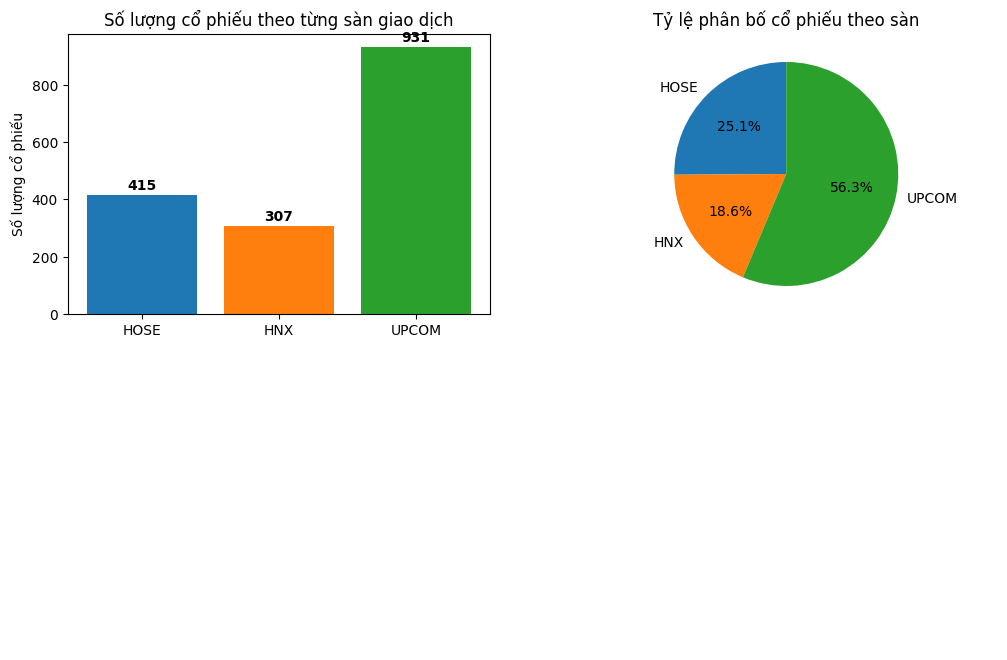

In [4]:
    # Tạo visualization cho số lượng cổ phiếu theo từng sàn
    stock_counts = {
        'HOSE': len(hose_stocks),
        'HNX': len(hnx_stocks),
        'UPCOM': len(upcom_stocks)
    }
    
    # Tạo biểu đồ
    plt.figure(figsize=(12, 8))
    
    # Subplot 1: Bar chart số lượng cổ phiếu theo sàn
    plt.subplot(2, 2, 1)
    exchanges = list(stock_counts.keys())
    counts = list(stock_counts.values())
    bars = plt.bar(exchanges, counts, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    plt.title('Số lượng cổ phiếu theo từng sàn giao dịch')
    plt.ylabel('Số lượng cổ phiếu')
    
    # Thêm số liệu trên mỗi cột
    for bar, count in zip(bars, counts):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                str(count), ha='center', va='bottom', fontweight='bold')
    
    # Subplot 2: Pie chart tỷ lệ phân bố
    plt.subplot(2, 2, 2)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    plt.pie(counts, labels=exchanges, autopct='%1.1f%%', colors=colors, startangle=90)
    plt.title('Tỷ lệ phân bố cổ phiếu theo sàn')
    
    # Subplot 3: Thống kê tổng quan
    plt.subplot(2, 1, 2)
    plt.axis('off')
    plt.show()

In [5]:
# Thiết lập thời gian lấy dữ liệu - từ 1/1/2022 đến 31/12/2024
from datetime import datetime, timedelta

# Thời gian cụ thể
start_date = datetime(2022, 1, 1)
end_date = datetime(2024, 12, 31)

print(f"Lấy dữ liệu từ: {start_date.strftime('%Y-%m-%d')} đến {end_date.strftime('%Y-%m-%d')}")

# Hàm tính RSI
def calculate_rsi(prices, window=14):
    """Tính chỉ số RSI"""
    delta = prices.diff()
    gains = delta.where(delta > 0, 0)
    losses = -delta.where(delta < 0, 0)
    
    avg_gains = gains.rolling(window=window).mean()
    avg_losses = losses.rolling(window=window).mean()
    
    rs = avg_gains / avg_losses
    rsi = 100 - (100 / (1 + rs))
    return rsi

# Hàm tính PSAR - theo chiến lược RSI-PSAR-Engulfing
def calculate_psar(high, low, close, af_start=0.02, af_step=0.02, af_max=0.20):
    """
    Tính chỉ số Parabolic SAR theo specs:
    - Initial AF: 0.02
    - Max AF: 0.20  
    - Step: 0.02
    """
    if len(close) < 2:
        return pd.Series([np.nan] * len(close), index=close.index)
        
    psar = close.copy()
    psaraf = pd.Series([af_start] * len(close), index=close.index)
    psarep = close.copy()
    bull = True  # Bắt đầu với xu hướng tăng
    
    # Khởi tạo giá trị đầu tiên
    psar.iloc[0] = low.iloc[0]
    psarep.iloc[0] = high.iloc[0]
    
    for i in range(1, len(close)):
        if bull:  # Xu hướng tăng
            # Tính PSAR cho ngày hiện tại
            psar.iloc[i] = psar.iloc[i-1] + psaraf.iloc[i-1] * (psarep.iloc[i-1] - psar.iloc[i-1])
            
            # Đảm bảo PSAR không vượt quá giá thấp của 2 ngày gần nhất
            if i >= 2:
                psar.iloc[i] = min(psar.iloc[i], low.iloc[i-1], low.iloc[i-2])
            else:
                psar.iloc[i] = min(psar.iloc[i], low.iloc[i-1])
            
            # Kiểm tra đảo chiều
            if low.iloc[i] <= psar.iloc[i]:
                bull = False  # Chuyển sang xu hướng giảm
                psar.iloc[i] = psarep.iloc[i-1]  # PSAR = EP cao nhất trước đó
                psarep.iloc[i] = low.iloc[i]     # EP mới = giá thấp hiện tại
                psaraf.iloc[i] = af_start        # Reset AF
            else:
                # Cập nhật EP và AF trong xu hướng tăng
                if high.iloc[i] > psarep.iloc[i-1]:
                    psarep.iloc[i] = high.iloc[i]  # EP mới
                    psaraf.iloc[i] = min(psaraf.iloc[i-1] + af_step, af_max)
                else:
                    psarep.iloc[i] = psarep.iloc[i-1]  # Giữ nguyên EP
                    psaraf.iloc[i] = psaraf.iloc[i-1]  # Giữ nguyên AF
        else:  # Xu hướng giảm
            # Tính PSAR cho ngày hiện tại
            psar.iloc[i] = psar.iloc[i-1] + psaraf.iloc[i-1] * (psarep.iloc[i-1] - psar.iloc[i-1])
            
            # Đảm bảo PSAR không vượt quá giá cao của 2 ngày gần nhất
            if i >= 2:
                psar.iloc[i] = max(psar.iloc[i], high.iloc[i-1], high.iloc[i-2])
            else:
                psar.iloc[i] = max(psar.iloc[i], high.iloc[i-1])
            
            # Kiểm tra đảo chiều
            if high.iloc[i] >= psar.iloc[i]:
                bull = True   # Chuyển sang xu hướng tăng
                psar.iloc[i] = psarep.iloc[i-1]  # PSAR = EP thấp nhất trước đó
                psarep.iloc[i] = high.iloc[i]    # EP mới = giá cao hiện tại
                psaraf.iloc[i] = af_start        # Reset AF
            else:
                # Cập nhật EP và AF trong xu hướng giảm
                if low.iloc[i] < psarep.iloc[i-1]:
                    psarep.iloc[i] = low.iloc[i]   # EP mới
                    psaraf.iloc[i] = min(psaraf.iloc[i-1] + af_step, af_max)
                else:
                    psarep.iloc[i] = psarep.iloc[i-1]  # Giữ nguyên EP
                    psaraf.iloc[i] = psaraf.iloc[i-1]  # Giữ nguyên AF
    
    return psar

# Hàm tính Engulfing Pattern - theo chiến lược RSI-PSAR-Engulfing
def calculate_engulfing(open_prices, high_prices, low_prices, close_prices, min_body_ratio=0.5):
    """
    Tính mẫu hình Engulfing theo specs:
    - Bullish Engulfing: +1
    - Bearish Engulfing: -1  
    - None: 0
    - Minimum Body Size: 50% of previous candle
    """
    engulfing = pd.Series([0] * len(close_prices), index=close_prices.index)
    
    for i in range(1, len(close_prices)):
        # Tính kích thước thân nến
        current_body = abs(close_prices.iloc[i] - open_prices.iloc[i])
        previous_body = abs(close_prices.iloc[i-1] - open_prices.iloc[i-1])
        
        # Kiểm tra điều kiện kích thước thân nến tối thiểu
        if previous_body == 0 or current_body < (previous_body * min_body_ratio):
            continue
            
        # Bullish Engulfing Pattern
        if (close_prices.iloc[i] > open_prices.iloc[i] and          # Nến hiện tại là nến xanh
            close_prices.iloc[i-1] < open_prices.iloc[i-1] and      # Nến trước là nến đỏ
            close_prices.iloc[i] > close_prices.iloc[i-1] and       # Close hiện tại > Close trước
            open_prices.iloc[i] < open_prices.iloc[i-1] and         # Open hiện tại < Open trước
            current_body > previous_body):                          # Thân nến hiện tại lớn hơn nến trước
            engulfing.iloc[i] = 1
            
        # Bearish Engulfing Pattern
        elif (close_prices.iloc[i] < open_prices.iloc[i] and        # Nến hiện tại là nến đỏ
              close_prices.iloc[i-1] > open_prices.iloc[i-1] and    # Nến trước là nến xanh
              close_prices.iloc[i] < close_prices.iloc[i-1] and     # Close hiện tại < Close trước
              open_prices.iloc[i] > open_prices.iloc[i-1] and       # Open hiện tại > Open trước
              current_body > previous_body):                        # Thân nến hiện tại lớn hơn nến trước
            engulfing.iloc[i] = -1
    
    return engulfing

print("Các hàm tính toán chỉ báo kỹ thuật đã được định nghĩa")


Lấy dữ liệu từ: 2022-01-01 đến 2024-12-31
Các hàm tính toán chỉ báo kỹ thuật đã được định nghĩa


In [6]:
# Hàm lấy dữ liệu cho một cổ phiếu
def fetch_stock_data(ticker, start_date, end_date, client):
    """Lấy dữ liệu OHLCV cho 1 cổ phiếu"""
    try:
        # Lấy dữ liệu từ FiinQuantX
        data = client.Fetch_Trading_Data(
            realtime=False,
            tickers=[ticker],
            fields=['open', 'high', 'low', 'close', 'volume'],
            adjusted=True,
            by='1d',  # Dữ liệu theo ngày
            from_date=start_date.strftime('%Y-%m-%d'),
            to_date=end_date.strftime('%Y-%m-%d')
        ).get_data()
        
        if data is not None and len(data) > 0:
            # Đảm bảo có column ticker
            if isinstance(data, pd.DataFrame):
                data['ticker'] = ticker
                return data
            else:
                print(f"Dữ liệu cho {ticker} không đúng định dạng DataFrame")
                return None
        else:
            print(f"Không có dữ liệu cho {ticker}")
            return None
            
    except Exception as e:
        print(f"Lỗi lấy dữ liệu cho {ticker}: {e}")
        return None

# Hàm xử lý dữ liệu và tính toán chỉ báo
def process_stock_data(data, ticker):
    """Xử lý và tính toán các chỉ báo kỹ thuật"""
    if data is None or len(data) == 0:
        return None
        
    try:
        # Sắp xếp và đặt index
        if 'time' in data.columns:
            data = data.sort_values('time')
            data.set_index('time', inplace=True)
        elif 'date' in data.columns:
            data = data.sort_values('date')
            data.set_index('date', inplace=True)

        # Tính RSI, PSAR, Engulfing
        data['RSI_14'] = calculate_rsi(data['close'], window=14)
        data['PSAR_Value'] = calculate_psar(data['high'], data['low'], data['close'])
        data['Engulfing_Signal'] = calculate_engulfing(data['open'], data['high'], data['low'], data['close'])

        # Thêm chỉ báo phụ trợ
        data['Price_vs_PSAR'] = (data['close'] > data['PSAR_Value']).astype(int)
        data['PSAR_Trend_Change'] = (data['Price_vs_PSAR'] != data['Price_vs_PSAR'].shift(1)).astype(int)

        data['RSI_State'] = pd.cut(data['RSI_14'], 
                                   bins=[0, 30, 50, 70, 100], 
                                   labels=['Oversold', 'Trending_Down', 'Trending_Up', 'Overbought'])

        # Volume anomaly
        data['AvgVolume_20'] = data['volume'].rolling(window=20).mean()
        data['Volume_Anomaly'] = (data['volume'] > data['AvgVolume_20']).astype(int)

        # Engulfing nâng cao
        data['Engulfing_In_3_Candles'] = data['Engulfing_Signal'].rolling(window=3).max().fillna(0).astype(int)
        data['Engulfing_Body_Size_Ratio'] = (
            abs(data['close'] - data['open']) / abs(data['close'].shift(1) - data['open'].shift(1))
        ).replace([np.inf, -np.inf], np.nan)

        # Long Entry
        data['Long_Entry_Signal'] = (
            (data['close'] > data['PSAR_Value']) & 
            (data['RSI_14'] > 50)
        ).astype(int)

        data['Long_Entry_Enhanced'] = (
            (data['close'] > data['PSAR_Value']) & 
            (data['RSI_14'] > 50) &
            (data['Volume_Anomaly'] == 1) &
            (data['Engulfing_In_3_Candles'] == 1)
        ).astype(int)

        # Long Exit
        data['Long_Exit_Signal'] = (
            (data['RSI_14'] < 50) | 
            (data['Engulfing_Signal'] == -1)
        ).astype(int)

        # Thêm thông tin metadata
        data['ticker'] = ticker
        data['exchange'] = (
            'HOSE' if ticker in hose_stocks else
            'HNX' if ticker in hnx_stocks else
            'UPCOM' if ticker in upcom_stocks else
            'UNKNOWN'
        )

        data.reset_index(inplace=True)
        return data

    except Exception as e:
        print(f"Lỗi xử lý dữ liệu cho {ticker}: {e}")
        return None


In [ ]:
# Thực hiện lấy dữ liệu cho tất cả cổ phiếu
print("Bắt đầu lấy dữ liệu cho tất cả cổ phiếu...")
print(f"Tổng số cổ phiếu cần xử lý: {len(all_stocks)}")

# Cấu hình xử lý
batch_size = 50
total_batches = (len(all_stocks) + batch_size - 1) // batch_size

# Containers để lưu kết quả
all_data = []
successful_tickers = []
failed_tickers = []
batch_results = []

print(f"Sẽ xử lý {total_batches} batch, mỗi batch tối đa {batch_size} cổ phiếu")
print("=" * 60)

# Xử lý từng batch
for batch_idx in range(total_batches):
    batch_start = batch_idx * batch_size
    batch_end = min((batch_idx + 1) * batch_size, len(all_stocks))
    batch_tickers = all_stocks[batch_start:batch_end]
    
    # Progress info
    progress = (batch_idx + 1) / total_batches * 100
    print(f"BATCH {batch_idx + 1:2d}/{total_batches} | Progress: {progress:5.1f}% | Processing {len(batch_tickers)} stocks...")
    
    # Stats cho batch hiện tại
    batch_success = 0
    batch_failed = 0
    
    # Xử lý từng ticker trong batch
    for i, ticker in enumerate(batch_tickers):
        try:
            # Lấy và xử lý dữ liệu
            raw_data = fetch_stock_data(ticker, start_date, end_date, client)
            
            if raw_data is not None:
                processed_data = process_stock_data(raw_data, ticker)
                
                if processed_data is not None and len(processed_data) > 0:
                    all_data.append(processed_data)
                    successful_tickers.append(ticker)
                    batch_success += 1
                else:
                    failed_tickers.append(ticker)
                    batch_failed += 1
            else:
                failed_tickers.append(ticker)
                batch_failed += 1
                
        except Exception as e:
            failed_tickers.append(ticker)
            batch_failed += 1
            if batch_idx == 0 and i < 3:  # Chỉ hiển thị lỗi đầu tiên
                print(f"  Error with {ticker}: {str(e)[:50]}...")
        
        # Mini delay
        time.sleep(0.05)
    
    # Báo cáo batch
    batch_total = batch_success + batch_failed
    success_rate = batch_success / batch_total * 100 if batch_total > 0 else 0
    print(f"  ✓ Success: {batch_success:2d} | ✗ Failed: {batch_failed:2d} | Rate: {success_rate:5.1f}%")
    
    # Lưu kết quả batch
    batch_results.append({
        'batch': batch_idx + 1,
        'success': batch_success,
        'failed': batch_failed,
        'rate': success_rate
    })
    
    # Delay giữa các batch
    if batch_idx < total_batches - 1:
        time.sleep(1)

# Tổng kết
print("=" * 60)
print("KẾT QUẢ CUỐI CÙNG:")
print(f"✓ Thành công: {len(successful_tickers):3d}/{len(all_stocks)} cổ phiếu ({len(successful_tickers)/len(all_stocks)*100:.1f}%)")
print(f"✗ Thất bại:   {len(failed_tickers):3d}/{len(all_stocks)} cổ phiếu ({len(failed_tickers)/len(all_stocks)*100:.1f}%)")
print(f" Tổng dữ liệu: {len(all_data)} DataFrames")

if failed_tickers:
    print(f"\nMột số mã thất bại: {failed_tickers[:10]}{'...' if len(failed_tickers) > 10 else ''}")

print("Hoàn thành thu thập dữ liệu!")


In [ ]:
if all_data:
    print("Đang tập hợp tất cả dữ liệu...")
    
    # Gộp tất cả DataFrame
    final_df = pd.concat(all_data, ignore_index=True)
    
    print(f"Kích thước dữ liệu cuối cùng: {final_df.shape}")
    print(f"Cột dữ liệu: {list(final_df.columns)}")
    
    # Kiểm tra dữ liệu
    print(f"\\nThống kê theo sàn giao dịch:")
    print(final_df['exchange'].value_counts())
    
    print(f"\\nSố lượng cổ phiếu có dữ liệu: {final_df['ticker'].nunique()}")
    print(f"Khoảng thời gian dữ liệu: {final_df.iloc[:, 0].min()} đến {final_df.iloc[:, 0].max()}")
    
    # Sắp xếp dữ liệu theo ticker và thời gian
    if 'time' in final_df.columns:
        final_df = final_df.sort_values(['ticker', 'time'])
    elif 'date' in final_df.columns:
        final_df = final_df.sort_values(['ticker', 'date'])
    else:
        final_df = final_df.sort_values(['ticker', final_df.columns[0]])
    
    
    # Lưu thành file CSV
    csv_filename = f"vietnam_stocks_data.csv"
    
    print(f"\\nĐang lưu dữ liệu vào file: {csv_filename}")
    final_df.to_csv(csv_filename, index=False, encoding='utf-8-sig')
    
    print(f"✓ Đã lưu thành công! File: {csv_filename}")
    print(f"✓ Kích thước file: {final_df.shape[0]:,} dòng x {final_df.shape[1]} cột")

# 3-4. Xây Dựng Chiến Lược Giao Dịch RSI-PSAR-Engulfing

## Mục tiêu
- Xây dựng chiến lược giao dịch dựa trên RSI, PSAR và Engulfing Pattern
- Áp dụng Machine Learning để tối ưu hóa việc lọc cổ phiếu
- Sử dụng các kỹ thuật phân cụm và giảm chiều dữ liệu
- Tạo hệ thống scoring và ranking cổ phiếu

In [7]:
# Import thư viện cơ bản
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime, timedelta
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import mean_squared_error, r2_score, roc_auc_score, silhouette_score

# Advanced ML Libraries
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import VotingClassifier, StackingClassifier

# Technical Analysis
import talib
from scipy import stats
from scipy.stats import zscore

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)


In [8]:
# Load dữ liệu
print("Loading Vietnam stocks data...")
df = pd.read_csv('vietnam_stocks_data.csv')

print(f"Data shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Number of unique tickers: {df['ticker'].nunique()}")
print(f"Exchanges: {df['exchange'].value_counts().to_dict()}")

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Basic info
print("\nData Info:")
df.info()



Loading Vietnam stocks data...
Data shape: (1161354, 22)
Columns: ['index', 'ticker', 'timestamp', 'open', 'high', 'low', 'close', 'volume', 'RSI_14', 'PSAR_Value', 'Engulfing_Signal', 'Price_vs_PSAR', 'PSAR_Trend_Change', 'RSI_State', 'AvgVolume_20', 'Volume_Anomaly', 'Engulfing_In_3_Candles', 'Engulfing_Body_Size_Ratio', 'Long_Entry_Signal', 'Long_Entry_Enhanced', 'Long_Exit_Signal', 'exchange']
Date range: 2022-01-04 00:00 to 2024-12-31 00:00
Number of unique tickers: 1592
Exchanges: {'UPCOM': 635842, 'HOSE': 299441, 'HNX': 226071}

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1161354 entries, 0 to 1161353
Data columns (total 22 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   index                      1161354 non-null  int64         
 1   ticker                     1161354 non-null  object        
 2   timestamp                  1161354 non-null  datetime64[ns]
 3   open

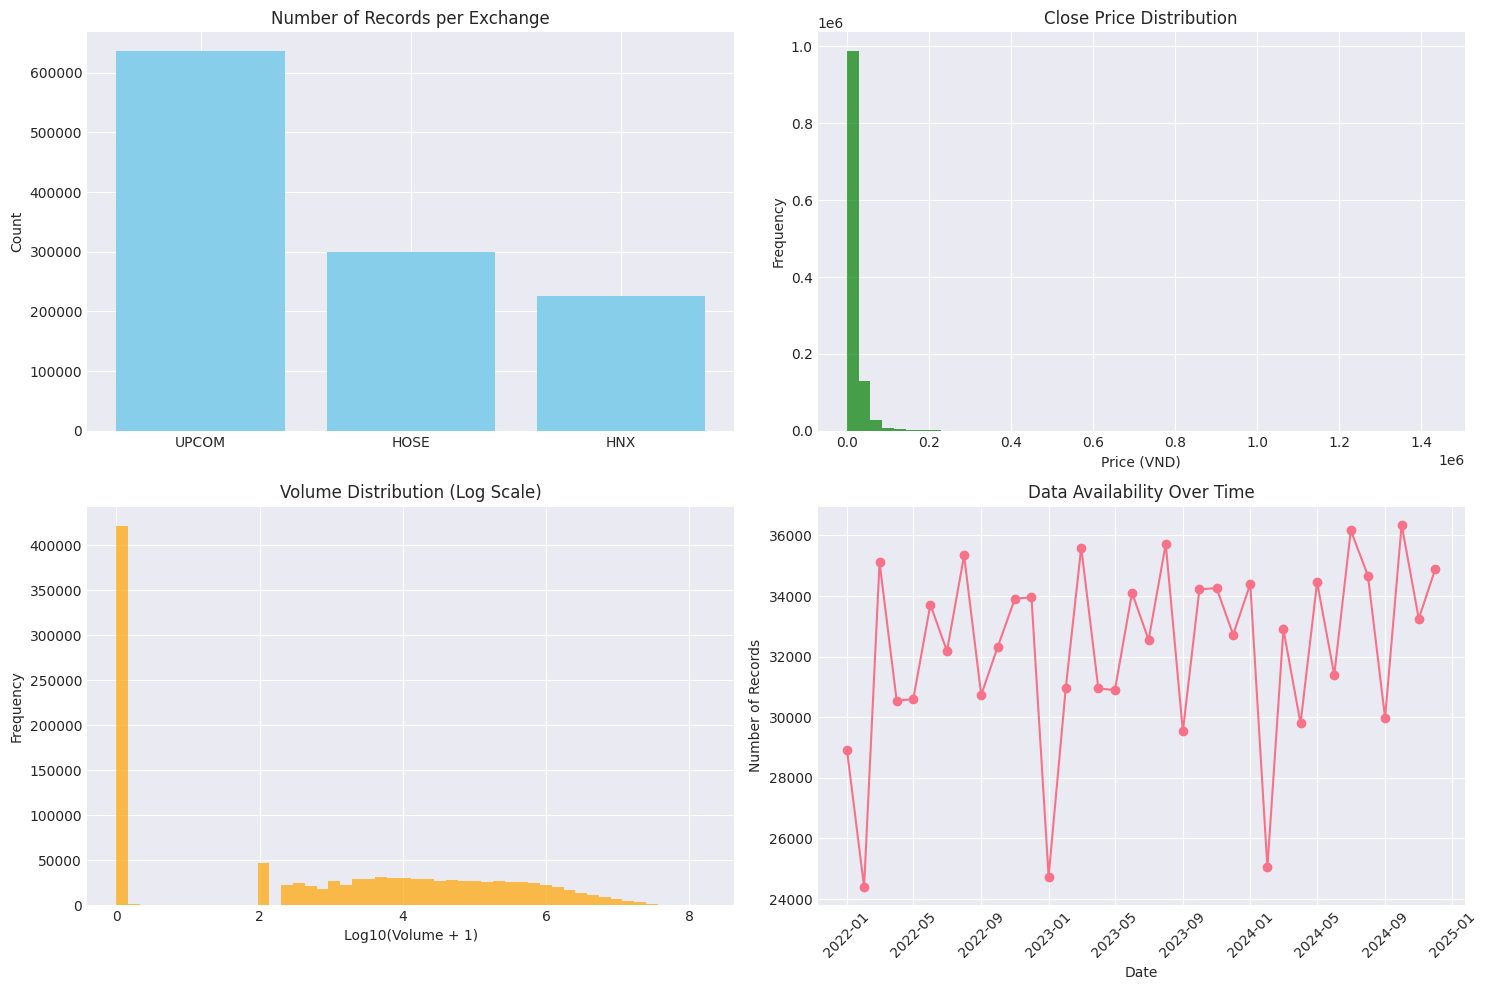

In [9]:
# Tạo visualizations cho data overview
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Number of stocks per exchange
exchange_counts = df['exchange'].value_counts()
axes[0,0].bar(exchange_counts.index, exchange_counts.values, color='skyblue')
axes[0,0].set_title('Number of Records per Exchange')
axes[0,0].set_ylabel('Count')

# 2. Price distribution
axes[0,1].hist(df['close'].dropna(), bins=50, alpha=0.7, color='green')
axes[0,1].set_title('Close Price Distribution')
axes[0,1].set_xlabel('Price (VND)')
axes[0,1].set_ylabel('Frequency')

# 3. Volume distribution
axes[1,0].hist(np.log10(df['volume'].dropna() + 1), bins=50, alpha=0.7, color='orange')
axes[1,0].set_title('Volume Distribution (Log Scale)')
axes[1,0].set_xlabel('Log10(Volume + 1)')
axes[1,0].set_ylabel('Frequency')

# 4. Data availability over time
monthly_data = df.groupby(df['timestamp'].dt.to_period('M')).size()
axes[1,1].plot(monthly_data.index.to_timestamp(), monthly_data.values, marker='o')
axes[1,1].set_title('Data Availability Over Time')
axes[1,1].set_xlabel('Date')
axes[1,1].set_ylabel('Number of Records')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



In [10]:
# Kiểm tra missing values và thống kê mô tả
print("Missing values:")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percent
})
print(missing_df[missing_df['Missing Count'] > 0])

# Thống kê mô tả cho các chỉ báo kỹ thuật
print("\nDescriptive Statistics for Technical Indicators:")
tech_indicators = ['RSI_14', 'PSAR_Value', 'Engulfing_Signal', 'Price_vs_PSAR', 'Volume_Anomaly']
print(df[tech_indicators].describe())


Missing values:
                           Missing Count  Missing Percentage
RSI_14                            187254           16.123766
PSAR_Value                             1            0.000086
RSI_State                         233243           20.083713
AvgVolume_20                       30167            2.597571
Engulfing_Body_Size_Ratio         601258           51.772156

Descriptive Statistics for Technical Indicators:
              RSI_14    PSAR_Value  Engulfing_Signal  Price_vs_PSAR  Volume_Anomaly
count  974100.000000  1.161353e+06      1.161354e+06   1.161354e+06    1.161354e+06
mean       49.306182  1.801500e+04     -6.483811e-04   4.598856e-01    2.493830e-01
std        23.555654  2.576120e+04      2.302562e-01   4.983885e-01    4.326561e-01
min         0.000000  2.892407e+01     -1.000000e+00   0.000000e+00    0.000000e+00
25%        35.897436  6.944630e+03      0.000000e+00   0.000000e+00    0.000000e+00
50%        49.659864  1.195209e+04      0.000000e+00   0.000000e

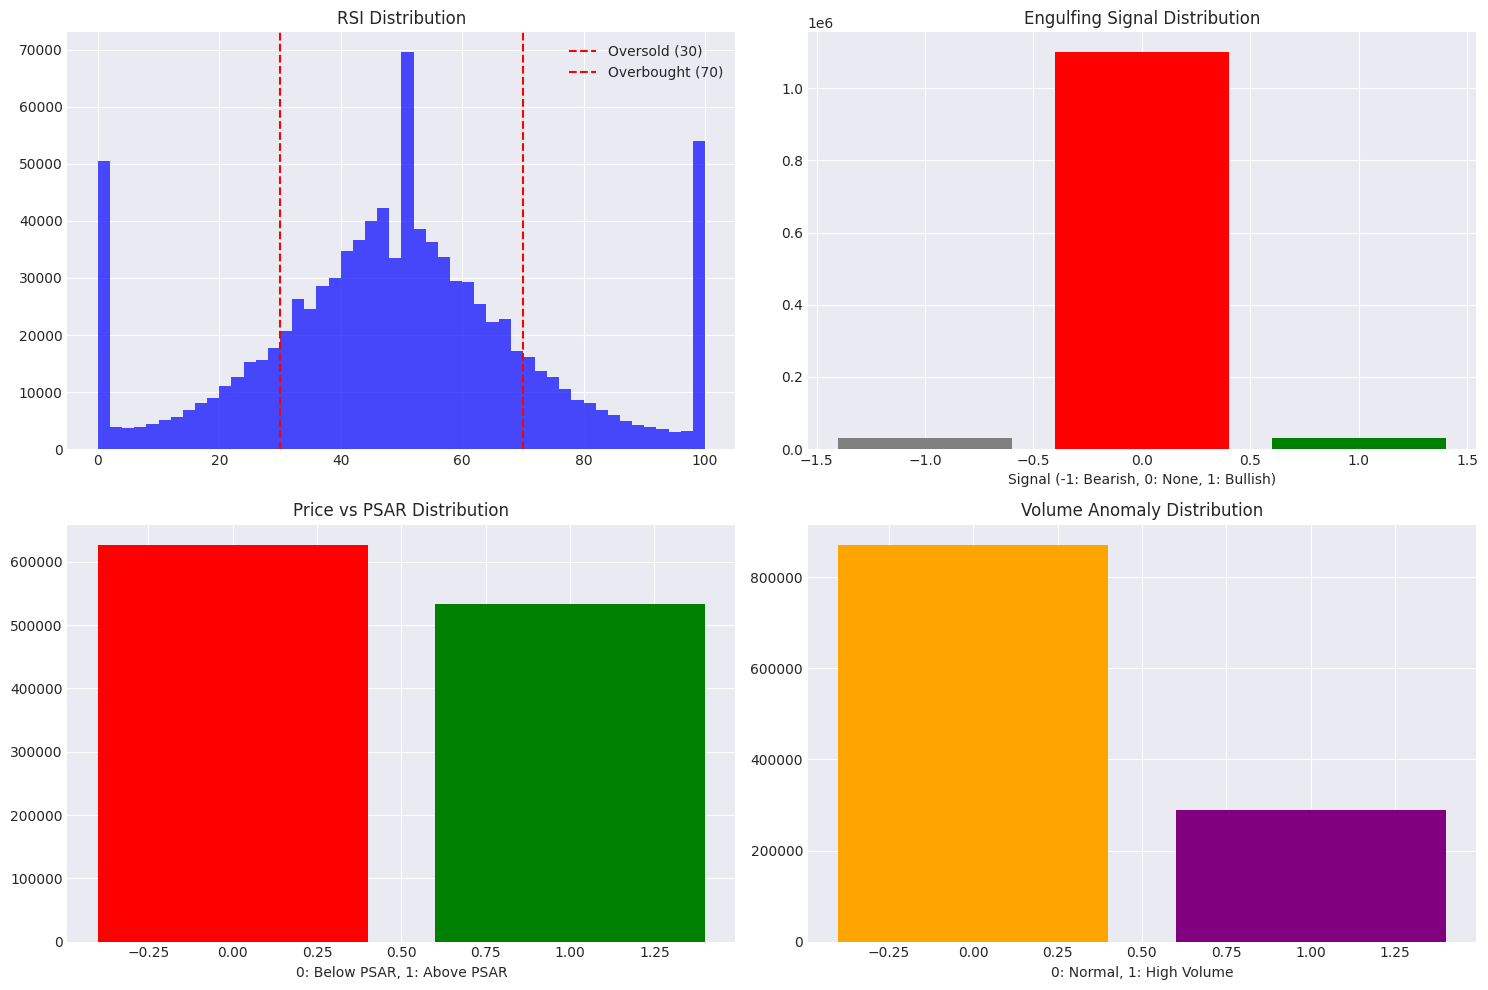

In [11]:
# Phân tích phân phối RSI và signals
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# RSI Distribution
axes[0,0].hist(df['RSI_14'].dropna(), bins=50, alpha=0.7, color='blue')
axes[0,0].axvline(30, color='red', linestyle='--', label='Oversold (30)')
axes[0,0].axvline(70, color='red', linestyle='--', label='Overbought (70)')
axes[0,0].set_title('RSI Distribution')
axes[0,0].legend()

# Engulfing Signal Distribution
engulfing_counts = df['Engulfing_Signal'].value_counts()
axes[0,1].bar(engulfing_counts.index, engulfing_counts.values, 
              color=['red', 'gray', 'green'])
axes[0,1].set_title('Engulfing Signal Distribution')
axes[0,1].set_xlabel('Signal (-1: Bearish, 0: None, 1: Bullish)')

# Price vs PSAR
psar_counts = df['Price_vs_PSAR'].value_counts()
axes[1,0].bar(psar_counts.index, psar_counts.values, 
              color=['red', 'green'])
axes[1,0].set_title('Price vs PSAR Distribution')
axes[1,0].set_xlabel('0: Below PSAR, 1: Above PSAR')

# Volume Anomaly
vol_counts = df['Volume_Anomaly'].value_counts()
axes[1,1].bar(vol_counts.index, vol_counts.values, 
              color=['orange', 'purple'])
axes[1,1].set_title('Volume Anomaly Distribution')
axes[1,1].set_xlabel('0: Normal, 1: High Volume')

plt.tight_layout()
plt.show()

In [12]:
# Feature Engineering - Tạo thêm các features từ RSI, PSAR, Engulfing
def create_advanced_features(df):
    """
    Tạo các features nâng cao cho mô hình ML dựa trên chiến lược RSI–PSAR–Engulfing
    """
    df_features = df.copy()
    
    # Sắp xếp theo mã cổ phiếu và thời gian
    df_features = df_features.sort_values(['ticker', 'timestamp'])

    # === Biến giá cơ bản ===
    df_features['returns'] = df_features.groupby('ticker')['close'].pct_change()
    df_features['log_returns'] = np.log(df_features['close'] / df_features.groupby('ticker')['close'].shift(1))
    df_features['price_change'] = df_features['close'] - df_features['open']
    df_features['price_range'] = df_features['high'] - df_features['low']

    # === Biến RSI ===
    df_features['RSI_momentum'] = df_features.groupby('ticker')['RSI_14'].diff()
    df_features['RSI_oversold'] = (df_features['RSI_14'] < 30).astype(int)
    df_features['RSI_overbought'] = (df_features['RSI_14'] > 70).astype(int)
    df_features['RSI_neutral'] = ((df_features['RSI_14'] >= 40) & (df_features['RSI_14'] <= 60)).astype(int)
    df_features['RSI_bullish_zone'] = ((df_features['RSI_14'] > 50) & (df_features['RSI_14'] < 70)).astype(int)
    df_features['RSI_bearish_zone'] = ((df_features['RSI_14'] < 50) & (df_features['RSI_14'] > 30)).astype(int)
    df_features['RSI_oversold_30'] = (df_features['RSI_14'] <= 30).astype(int)
    df_features['RSI_overbought_70'] = (df_features['RSI_14'] >= 70).astype(int)

    # === Biến PSAR ===
    df_features['PSAR_distance'] = df_features['close'] - df_features['PSAR_Value']
    df_features['PSAR_distance_pct'] = df_features['PSAR_distance'] / df_features['close'] * 100
    df_features['PSAR_trend_change'] = df_features.groupby('ticker')['Price_vs_PSAR'].diff().abs().fillna(0)

    # === Biến Volume ===
    df_features['volume_ratio'] = df_features['volume'] / (df_features['AvgVolume_20'] + 1)
    df_features['volume_price_trend'] = df_features['volume'] * df_features['returns']

    # === Biến Volatility (Rolling Std) ===
    df_features['volatility_5'] = (
        df_features.groupby('ticker')['returns']
        .rolling(5)
        .std()
        .reset_index(level=0, drop=True)
    )

    df_features['volatility_20'] = (
        df_features.groupby('ticker')['returns']
        .rolling(20)
        .std()
        .reset_index(level=0, drop=True)
    )

    # === Moving Averages ===
    for window in [5, 10, 20]:
        df_features[f'SMA_{window}'] = (
            df_features
            .groupby('ticker')['close']
            .rolling(window)
            .mean()
            .reset_index(level=0, drop=True)
        )

    # === Price vs MA signals ===
    df_features['price_above_SMA5'] = (df_features['close'] > df_features['SMA_5']).astype(int)
    df_features['price_above_SMA10'] = (df_features['close'] > df_features['SMA_10']).astype(int)
    df_features['price_above_SMA20'] = (df_features['close'] > df_features['SMA_20']).astype(int)

    # === Trend strength ===
    df_features['trend_strength'] = (
        df_features['price_above_SMA5'] + 
        df_features['price_above_SMA10'] + 
        df_features['price_above_SMA20'] + 
        df_features['Price_vs_PSAR']
    )

    df_features['weighted_trend_strength'] = (
        df_features['price_above_SMA5'] * 0.4 + 
        df_features['price_above_SMA10'] * 0.3 + 
        df_features['price_above_SMA20'] * 0.2 + 
        df_features['Price_vs_PSAR'] * 0.1
    )

    # === Engulfing Patterns ===
    df_features['Bullish_Engulfing'] = (df_features['Engulfing_Signal'] == 1).astype(int)
    df_features['Bearish_Engulfing'] = (df_features['Engulfing_Signal'] == -1).astype(int)

    # === Combined Signals (Chiến lược) ===
    df_features['bullish_signal'] = (
        (df_features['RSI_14'] > 50) & 
        (df_features['Price_vs_PSAR'] == 1) & 
        (df_features['Engulfing_Signal'] >= 0)
    ).astype(int)

    df_features['bearish_signal'] = (
        (df_features['RSI_14'] < 50) & 
        (df_features['Price_vs_PSAR'] == 0) & 
        (df_features['Engulfing_Signal'] <= 0)
    ).astype(int)

    # === Interaction Features ===
    df_features['RSI_PSAR_interaction'] = df_features['RSI_14'] * df_features['Price_vs_PSAR']
    df_features['Engulfing_Volume'] = df_features['Engulfing_Signal'] * df_features['volume_ratio']

    # === Xử lý missing cuối cùng (nếu cần) ===
    df_features = df_features.fillna(0)

    return df_features

# Apply feature engineering
df_features = create_advanced_features(df)

# Kiểm tra kết quả
print(f"Features created. New shape: {df_features.shape}")
new_cols = [col for col in df_features.columns if col not in df.columns]
print(f"New columns:\n{new_cols}")


Features created. New shape: (1161354, 55)
New columns:
['returns', 'log_returns', 'price_change', 'price_range', 'RSI_momentum', 'RSI_oversold', 'RSI_overbought', 'RSI_neutral', 'RSI_bullish_zone', 'RSI_bearish_zone', 'RSI_oversold_30', 'RSI_overbought_70', 'PSAR_distance', 'PSAR_distance_pct', 'PSAR_trend_change', 'volume_ratio', 'volume_price_trend', 'volatility_5', 'volatility_20', 'SMA_5', 'SMA_10', 'SMA_20', 'price_above_SMA5', 'price_above_SMA10', 'price_above_SMA20', 'trend_strength', 'weighted_trend_strength', 'Bullish_Engulfing', 'Bearish_Engulfing', 'bullish_signal', 'bearish_signal', 'RSI_PSAR_interaction', 'Engulfing_Volume']


In [13]:
# Tạo target variables cho classification và regression
def create_targets(df, forward_days=[1, 3, 5, 10]):
    """
    Tạo target variables cho ML:
    - Regression (future_return)
    - Classification (binary, multi-class)
    """
    df_targets = df.copy()
    df_targets = df_targets.sort_values(['ticker', 'timestamp'])

    # Tạo target
    for days in forward_days:
        future_close = df_targets.groupby('ticker')['close'].shift(-days)
        df_targets[f'future_return_{days}d'] = (future_close - df_targets['close']) / df_targets['close'] * 100

        # Nhị phân: mua / bán
        df_targets[f'target_buy_{days}d'] = (df_targets[f'future_return_{days}d'] > 2).astype(int)
        df_targets[f'target_sell_{days}d'] = (df_targets[f'future_return_{days}d'] < -2).astype(int)

        # Đa lớp: Strong Sell → Strong Buy
        df_targets[f'target_class_{days}d'] = pd.cut(
            df_targets[f'future_return_{days}d'],
            bins=[-np.inf, -5, -2, 2, 5, np.inf],
            labels=['Strong_Sell', 'Sell', 'Hold', 'Buy', 'Strong_Buy'],
            ordered=True
        )
    
    # Target mặc định (3 ngày)
    df_targets['target_return'] = df_targets['future_return_3d']
    df_targets['target_binary'] = df_targets['target_buy_3d']
    df_targets['target_multiclass'] = df_targets['target_class_3d']

    # Xoá các dòng NaN cuối chuỗi
    df_targets = df_targets.dropna(subset=['target_return', 'target_binary', 'target_multiclass'])

    return df_targets

# Create targets
print("Creating target variables...")
df_ml = create_targets(df_features)

# Display target distribution
print("\nTarget distribution (3-day forward returns):")
print(f"Mean return: {df_ml['target_return'].mean():.4f}%")
print(f"Std return: {df_ml['target_return'].std():.4f}%")
print(f"\nBinary target distribution:")
print(df_ml['target_binary'].value_counts())
print(f"\nMulti-class target distribution:")
print(df_ml['target_multiclass'].value_counts())


Creating target variables...

Target distribution (3-day forward returns):
Mean return: 0.0605%
Std return: 6.0412%

Binary target distribution:
target_binary
0    920843
1    235738
Name: count, dtype: int64

Multi-class target distribution:
target_multiclass
Hold           672616
Strong_Sell    128869
Strong_Buy     126427
Sell           119358
Buy            109311
Name: count, dtype: int64


In [14]:
# Thiết kế logic lọc cổ phiếu theo chiến lược RSI-PSAR-Engulfing
class RSI_PSAR_Engulfing_Filter:
    def __init__(self):
        self.name = "RSI-PSAR-Engulfing Filter"
    
    def basic_filter(self, df):
        """
        Lọc cổ phiếu theo các điều kiện chiến lược RSI–PSAR–Engulfing
        """
        conditions = {
            'strong_buy': (
                (df['RSI_14'] > 50) & (df['RSI_14'] < 80) &
                (df['Price_vs_PSAR'] == 1) &
                (df['Engulfing_In_3_Candles'] == 1) &
                (df['Volume_Anomaly'] == 1)
            ),
            'buy': (
                (df['RSI_14'] > 45) & (df['RSI_14'] < 75) &
                (df['Price_vs_PSAR'] == 1) &
                (df['Engulfing_Signal'] >= 0)
            ),
            'hold': (
                (df['RSI_14'] > 30) & (df['RSI_14'] < 70) &
                (df['trend_strength'] >= 2)
            ),
            'sell': (
                (df['RSI_14'] < 55) & (df['RSI_14'] > 25) &
                (df['Price_vs_PSAR'] == 0) &
                (df['Engulfing_Signal'] <= 0)
            ),
            'strong_sell': (
                (df['RSI_14'] < 50) & (df['RSI_14'] > 20) &
                (df['Price_vs_PSAR'] == 0) &
                (df['Engulfing_Signal'] == -1) &
                (df['Volume_Anomaly'] == 1)
            )
        }
        return conditions

    def scoring_system(self, df):
        """
        Chấm điểm cổ phiếu theo chiến lược:
        Tổng điểm tối đa: 100
        """
        # RSI Score (max 25)
        rsi_score = np.select([
            df['RSI_14'] < 20,
            (df['RSI_14'] >= 20) & (df['RSI_14'] < 30),
            (df['RSI_14'] >= 30) & (df['RSI_14'] < 50),
            (df['RSI_14'] >= 50) & (df['RSI_14'] < 70),
            (df['RSI_14'] >= 70) & (df['RSI_14'] < 80),
            df['RSI_14'] >= 80
        ], [8, 15, 18, 25, 12, 5], default=0)

        # PSAR Score (max 25)
        psar_score = df['Price_vs_PSAR'] * 25

        # Engulfing Score (max 20)
        engulfing_score = np.select([
            df['Engulfing_Signal'] == 1,
            df['Engulfing_Signal'] == 0,
            df['Engulfing_Signal'] == -1
        ], [20, 5, 0], default=5)

        # Volume Score (max 15)
        volume_score = df['Volume_Anomaly'] * 15

        # Trend Score (max 15)
        trend_score = (df['trend_strength'].clip(0, 4) / 4) * 15

        # Tổng điểm
        total_score = rsi_score + psar_score + engulfing_score + volume_score + trend_score

        return {
            'total_score': total_score,
            'rsi_score': rsi_score,
            'psar_score': psar_score,
            'engulfing_score': engulfing_score,
            'volume_score': volume_score,
            'trend_score': trend_score
        }

    def probability_signals(self, df):
        """
        Tính xác suất xác nhận tín hiệu mua/bán theo chiến lược
        """
        # RSI probability
        rsi_prob = np.select([
            df['RSI_14'] < 20,
            (df['RSI_14'] >= 20) & (df['RSI_14'] < 30),
            (df['RSI_14'] >= 30) & (df['RSI_14'] < 50),
            (df['RSI_14'] >= 50) & (df['RSI_14'] < 70),
            (df['RSI_14'] >= 70) & (df['RSI_14'] < 80),
            df['RSI_14'] >= 80
        ], [0.25, 0.45, 0.40, 0.75, 0.35, 0.20], default=0.5)

        # PSAR probability
        psar_prob = np.where(df['Price_vs_PSAR'] == 1, 0.65, 0.35)

        # Engulfing probability
        engulfing_prob = np.select([
            df['Engulfing_Signal'] == 1,
            df['Engulfing_Signal'] == 0,
            df['Engulfing_Signal'] == -1
        ], [0.70, 0.50, 0.30], default=0.5)

        # Volume probability
        volume_prob = np.where(df['Volume_Anomaly'] == 1, 0.65, 0.45)

        # Weighted combined probability
        combined_prob = (
            rsi_prob * 0.35 +
            psar_prob * 0.30 +
            engulfing_prob * 0.25 +
            volume_prob * 0.10
        )

        return {
            'rsi_probability': rsi_prob,
            'psar_probability': psar_prob,
            'engulfing_probability': engulfing_prob,
            'volume_probability': volume_prob,
            'combined_probability': combined_prob
        }

# Khởi tạo bộ lọc
filter_system = RSI_PSAR_Engulfing_Filter()

# Áp dụng lọc theo điều kiện logic
conditions = filter_system.basic_filter(df_ml)
for cond, logic in conditions.items():
    df_ml[f'condition_{cond}'] = logic.astype(int)

# Tính điểm
scores = filter_system.scoring_system(df_ml)
for key, value in scores.items():
    df_ml[key] = value

# Tính xác suất tín hiệu
probs = filter_system.probability_signals(df_ml)
for key, value in probs.items():
    df_ml[key] = value

print("✓ Đã áp dụng bộ lọc RSI–PSAR–Engulfing thành công.")

✓ Đã áp dụng bộ lọc RSI–PSAR–Engulfing thành công.


In [15]:
# Chuẩn bị dữ liệu cho ML
def prepare_ml_data(df):
    """
    Chuẩn bị dữ liệu cho machine learning
    """
    feature_columns = [
        # RSI features
        'RSI_14', 'RSI_momentum', 'RSI_oversold', 'RSI_overbought', 'RSI_neutral',
        'RSI_oversold_30', 'RSI_overbought_70', 'RSI_bullish_zone', 'RSI_bearish_zone',
        
        # PSAR features
        'PSAR_distance', 'PSAR_distance_pct', 'Price_vs_PSAR', 'PSAR_trend_change',
        
        # Engulfing features
        'Engulfing_Signal', 'Bullish_Engulfing', 'Bearish_Engulfing',
        
        # Volume features
        'Volume_Anomaly', 'volume_ratio', 'volume_price_trend',
        
        # Price & volatility features
        'volatility_5', 'volatility_20', 'returns', 'price_change', 'price_range',
        
        # Moving average features
        'price_above_SMA5', 'price_above_SMA10', 'price_above_SMA20',
        'trend_strength', 'weighted_trend_strength',
        
        # Combined signals
        'bullish_signal', 'bearish_signal',
        
        # Scoring features
        'total_score', 'combined_probability'
    ]

    # Kiểm tra timestamp
    df['timestamp'] = pd.to_datetime(df['timestamp'])

    # Loại bỏ NaN
    df_clean = df.dropna(subset=['target_return', 'target_binary']).copy()
    df_clean = df_clean.dropna(subset=feature_columns)

    # Kiểm tra cột thiếu
    missing_cols = [col for col in feature_columns if col not in df_clean.columns]
    if missing_cols:
        raise ValueError(f"Thiếu cột: {missing_cols}")

    # Tạo X và y
    X = df_clean[feature_columns]
    y_regression = df_clean['target_return']
    y_classification = df_clean['target_binary']

    # Encode multi-class target
    le = LabelEncoder()
    y_multiclass = le.fit_transform(df_clean['target_multiclass'].fillna('Hold'))

    return X, y_regression, y_classification, y_multiclass, df_clean, le

# Gọi hàm chuẩn bị dữ liệu
print("Preparing ML data...")
X, y_reg, y_clf, y_multi, df_clean, le = prepare_ml_data(df_ml)

# Feature scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# Train-test split theo thời gian
split_date = '2024-01-01'
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])
train_mask = df_clean['timestamp'] < split_date
test_mask = df_clean['timestamp'] >= split_date

X_train, X_test = X_scaled[train_mask], X_scaled[test_mask]
y_reg_train, y_reg_test = y_reg[train_mask], y_reg[test_mask]
y_clf_train, y_clf_test = y_clf[train_mask], y_clf[test_mask]
y_multi_train, y_multi_test = y_multi[train_mask], y_multi[test_mask]

# In kết quả chia tập
print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Split date: {split_date}")
print(f"\nFeatures: {list(X.columns)}")
print(f"Regression target shape: {y_reg.shape}")
print(f"Binary target distribution: {pd.Series(y_clf).value_counts().to_dict()}")
print(f"Multi-class target distribution: {pd.Series(y_multi).value_counts().to_dict()}")


Preparing ML data...

Training set size: 768035
Test set size: 388546
Split date: 2024-01-01

Features: ['RSI_14', 'RSI_momentum', 'RSI_oversold', 'RSI_overbought', 'RSI_neutral', 'RSI_oversold_30', 'RSI_overbought_70', 'RSI_bullish_zone', 'RSI_bearish_zone', 'PSAR_distance', 'PSAR_distance_pct', 'Price_vs_PSAR', 'PSAR_trend_change', 'Engulfing_Signal', 'Bullish_Engulfing', 'Bearish_Engulfing', 'Volume_Anomaly', 'volume_ratio', 'volume_price_trend', 'volatility_5', 'volatility_20', 'returns', 'price_change', 'price_range', 'price_above_SMA5', 'price_above_SMA10', 'price_above_SMA20', 'trend_strength', 'weighted_trend_strength', 'bullish_signal', 'bearish_signal', 'total_score', 'combined_probability']
Regression target shape: (1156581,)
Binary target distribution: {0: 920843, 1: 235738}
Multi-class target distribution: {1: 672616, 4: 128869, 3: 126427, 2: 119358, 0: 109311}


In [16]:
# XGBoost Models
print("Training XGBoost models...")

# XGBoost Regressor for expected returns
xgb_reg = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)
xgb_reg.fit(X_train, y_reg_train)

# XGBoost Classifier for buy signals
xgb_clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='binary:logistic'
)
xgb_clf.fit(X_train, y_clf_train)

# Predictions
xgb_reg_pred = xgb_reg.predict(X_test)
xgb_clf_pred = xgb_clf.predict(X_test)
xgb_clf_proba = xgb_clf.predict_proba(X_test)[:, 1]

print("XGBoost models trained successfully!")

# Performance metrics
from sklearn.metrics import mean_absolute_error
xgb_reg_mse = mean_squared_error(y_reg_test, xgb_reg_pred)
xgb_reg_mae = mean_absolute_error(y_reg_test, xgb_reg_pred)
xgb_reg_r2 = r2_score(y_reg_test, xgb_reg_pred)

xgb_clf_acc = accuracy_score(y_clf_test, xgb_clf_pred)
xgb_clf_auc = roc_auc_score(y_clf_test, xgb_clf_proba)


Training XGBoost models...
XGBoost models trained successfully!


In [17]:
# LightGBM Models
print("Training LightGBM models...")

# LightGBM Regressor
lgb_reg = lgb.LGBMRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1,
    objective='regression'
)
lgb_reg.fit(X_train, y_reg_train)

# LightGBM Classifier
lgb_clf = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1,
    objective='binary'
)
lgb_clf.fit(X_train, y_clf_train)

# Predictions
lgb_reg_pred = lgb_reg.predict(X_test)
lgb_clf_pred = lgb_clf.predict(X_test)
lgb_clf_proba = lgb_clf.predict_proba(X_test)[:, 1]

print("LightGBM models trained successfully!")

# Performance metrics
lgb_reg_mse = mean_squared_error(y_reg_test, lgb_reg_pred)
lgb_reg_mae = mean_absolute_error(y_reg_test, lgb_reg_pred)
lgb_reg_r2 = r2_score(y_reg_test, lgb_reg_pred)

lgb_clf_acc = accuracy_score(y_clf_test, lgb_clf_pred)
lgb_clf_auc = roc_auc_score(y_clf_test, lgb_clf_proba)


Training LightGBM models...
LightGBM models trained successfully!


In [18]:
# PCA Analysis - Giảm chiều dữ liệu
print("Performing PCA analysis...")

# PCA với các số components khác nhau
pca_components = [5, 10, 15, 20]
pca_results = {}

for n_components in pca_components:
    pca = PCA(n_components=n_components, random_state=42)
    X_pca = pca.fit_transform(X_scaled)
    
    explained_variance_ratio = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance_ratio)
    
    pca_results[n_components] = {
        'pca': pca,
        'X_transformed': X_pca,
        'explained_variance_ratio': explained_variance_ratio,
        'cumulative_variance': cumulative_variance
    }
    
    print(f"PCA with {n_components} components - Explained variance: {cumulative_variance[-1]:.3f}")


Performing PCA analysis...
PCA with 5 components - Explained variance: 0.571
PCA with 10 components - Explained variance: 0.762
PCA with 15 components - Explained variance: 0.890
PCA with 20 components - Explained variance: 0.965


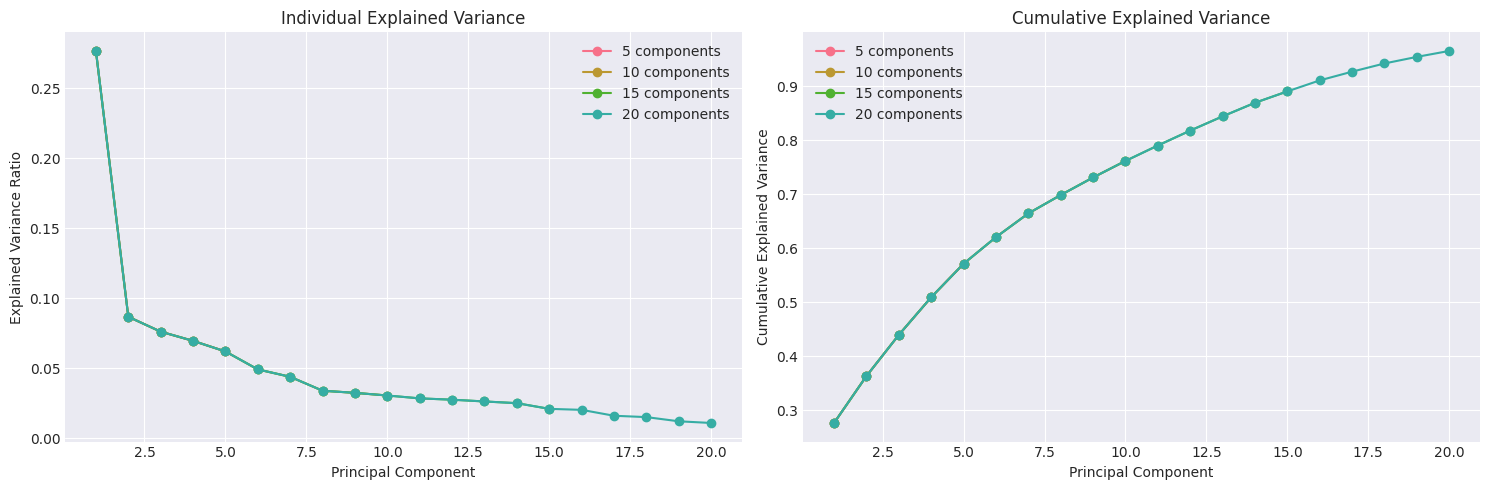


10-component PCA explained variance: 0.762


In [19]:
# Visualize PCA explained variance
plt.figure(figsize=(15, 5))

# Individual explained variance
plt.subplot(1, 2, 1)
for n_comp in pca_components:
    plt.plot(range(1, n_comp + 1), 
             pca_results[n_comp]['explained_variance_ratio'], 
             'o-', label=f'{n_comp} components')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Individual Explained Variance')
plt.legend()
plt.grid(True)

# Cumulative explained variance
plt.subplot(1, 2, 2)
for n_comp in pca_components:
    plt.plot(range(1, n_comp + 1), 
             pca_results[n_comp]['cumulative_variance'], 
             'o-', label=f'{n_comp} components')
plt.xlabel('Principal Component')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Sử dụng PCA với 10 components cho clustering
X_pca_10 = pca_results[10]['X_transformed']
print(f"\n10-component PCA explained variance: {pca_results[10]['cumulative_variance'][-1]:.3f}")


In [20]:
# Traditional ML Models
print("Training traditional ML models...")

# Logistic Regression
lr_clf = LogisticRegression(random_state=42, max_iter=1000, solver='liblinear')
lr_clf.fit(X_train, y_clf_train)

# Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train, y_clf_train)

rf_reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_reg.fit(X_train, y_reg_train)

# K-Nearest Neighbors
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train, y_clf_train)

print("Traditional ML models trained successfully!")

# Predictions and evaluations
lr_pred = lr_clf.predict(X_test)
lr_proba = lr_clf.predict_proba(X_test)[:, 1]
lr_acc = accuracy_score(y_clf_test, lr_pred)
lr_auc = roc_auc_score(y_clf_test, lr_proba)

rf_clf_pred = rf_clf.predict(X_test)
rf_clf_proba = rf_clf.predict_proba(X_test)[:, 1]
rf_clf_acc = accuracy_score(y_clf_test, rf_clf_pred)
rf_clf_auc = roc_auc_score(y_clf_test, rf_clf_proba)

rf_reg_pred = rf_reg.predict(X_test)
rf_reg_mse = mean_squared_error(y_reg_test, rf_reg_pred)
rf_reg_r2 = r2_score(y_reg_test, rf_reg_pred)

knn_pred = knn_clf.predict(X_test)
knn_proba = knn_clf.predict_proba(X_test)[:, 1]
knn_acc = accuracy_score(y_clf_test, knn_pred)
knn_auc = roc_auc_score(y_clf_test, knn_proba)


Training traditional ML models...
Traditional ML models trained successfully!


In [21]:
# Comprehensive Model Comparison với nhiều metrics
from sklearn.metrics import (precision_score, recall_score, f1_score, 
                           balanced_accuracy_score,
                           matthews_corrcoef, cohen_kappa_score)

def calculate_specificity(y_true, y_pred):
    """
    Calculate specificity score manually
    Specificity = TN / (TN + FP)
    """
    from sklearn.metrics import confusion_matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0

def calculate_comprehensive_metrics(y_true, y_pred, y_proba=None):
    """
    Tính toán tất cả các metrics quan trọng cho classification
    """
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='binary'),
        'recall': recall_score(y_true, y_pred, average='binary'),
        'f1_score': f1_score(y_true, y_pred, average='binary'),
        'specificity': calculate_specificity(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'matthews_corrcoef': matthews_corrcoef(y_true, y_pred),
        'cohen_kappa': cohen_kappa_score(y_true, y_pred)
    }
    
    if y_proba is not None:
        metrics['auc'] = roc_auc_score(y_true, y_proba)
    
    return metrics

def create_comprehensive_model_comparison():
    """
    Tạo bảng so sánh performance toàn diện của các models
    """
    # Tính toán metrics cho từng model
    models_metrics = {}
    
    # XGBoost
    models_metrics['XGBoost'] = calculate_comprehensive_metrics(
        y_clf_test, xgb_clf_pred, xgb_clf_proba
    )
    
    # LightGBM
    models_metrics['LightGBM'] = calculate_comprehensive_metrics(
        y_clf_test, lgb_clf_pred, lgb_clf_proba
    )
    
    # Logistic Regression
    models_metrics['Logistic Regression'] = calculate_comprehensive_metrics(
        y_clf_test, lr_pred, lr_proba
    )
    
    # Random Forest
    models_metrics['Random Forest'] = calculate_comprehensive_metrics(
        y_clf_test, rf_clf_pred, rf_clf_proba
    )
    
    # KNN
    models_metrics['KNN'] = calculate_comprehensive_metrics(
        y_clf_test, knn_pred, knn_proba
    )
    
    # Tạo DataFrame từ metrics
    classification_results = pd.DataFrame(models_metrics).T.round(4)
    
    # Regression results 
    regression_results = pd.DataFrame({
        'Model': ['XGBoost', 'LightGBM', 'Random Forest'],
        'MSE': [xgb_reg_mse, lgb_reg_mse, rf_reg_mse],
        'MAE': [xgb_reg_mae, lgb_reg_mae, mean_absolute_error(y_reg_test, rf_reg_pred)],
        'R²': [xgb_reg_r2, lgb_reg_r2, rf_reg_r2]
    })
    
    return classification_results, regression_results

# Tạo comprehensive comparison
clf_results_comprehensive, reg_results = create_comprehensive_model_comparison()

print("COMPREHENSIVE CLASSIFICATION MODELS COMPARISON")
print(clf_results_comprehensive.sort_values('f1_score', ascending=False))

print("TOP PERFORMERS BY DIFFERENT METRICS:")
print(f"Best F1 Score: {clf_results_comprehensive.sort_values('f1_score', ascending=False).index[0]} ({clf_results_comprehensive['f1_score'].max():.4f})")
print(f"Best Precision: {clf_results_comprehensive.sort_values('precision', ascending=False).index[0]} ({clf_results_comprehensive['precision'].max():.4f})")
print(f"Best Recall: {clf_results_comprehensive.sort_values('recall', ascending=False).index[0]} ({clf_results_comprehensive['recall'].max():.4f})")
print(f"Best AUC: {clf_results_comprehensive.sort_values('auc', ascending=False).index[0]} ({clf_results_comprehensive['auc'].max():.4f})")
print(f"Best Balanced Accuracy: {clf_results_comprehensive.sort_values('balanced_accuracy', ascending=False).index[0]} ({clf_results_comprehensive['balanced_accuracy'].max():.4f})")

print("REGRESSION MODELS COMPARISON")
print(reg_results.sort_values('R²', ascending=False))

COMPREHENSIVE CLASSIFICATION MODELS COMPARISON
                     accuracy  precision  recall  f1_score  specificity  balanced_accuracy  matthews_corrcoef  cohen_kappa     auc
KNN                    0.7683     0.2489  0.1439    0.1824       0.9050             0.5244             0.0615       0.0585  0.5932
XGBoost                0.8225     0.5794  0.0403    0.0753       0.9936             0.5169             0.1171       0.0532  0.7106
LightGBM               0.8221     0.5733  0.0361    0.0679       0.9941             0.5151             0.1097       0.0476  0.7100
Logistic Regression    0.8197     0.4229  0.0115    0.0224       0.9966             0.5040             0.0445       0.0130  0.6684
Random Forest          0.8211     0.6069  0.0103    0.0203       0.9985             0.5044             0.0617       0.0144  0.7060
TOP PERFORMERS BY DIFFERENT METRICS:
Best F1 Score: KNN (0.1824)
Best Precision: Random Forest (0.6069)
Best Recall: KNN (0.1439)
Best AUC: XGBoost (0.7106)
Best Balan

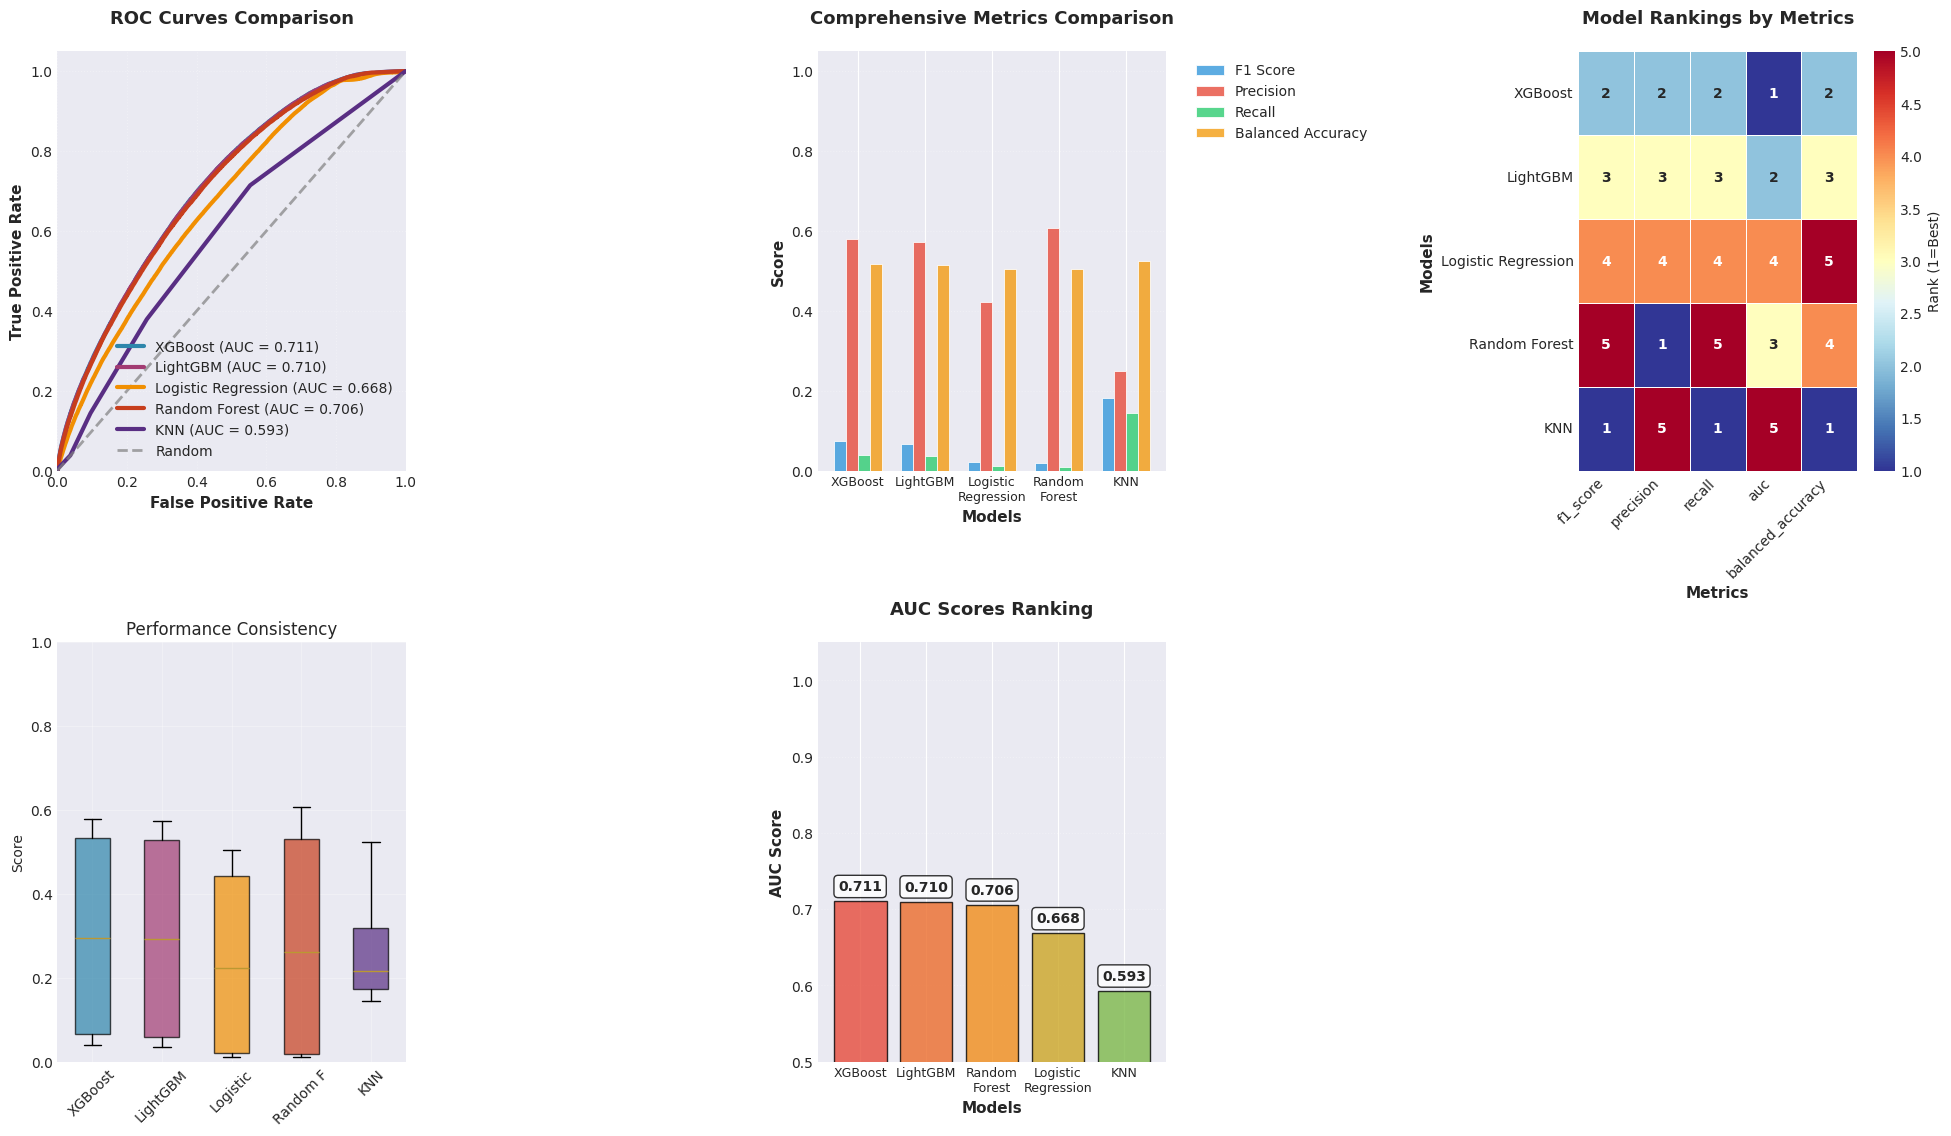

In [22]:
# ROC Curves Comparison và Advanced Visualization
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Tạo models_data dictionary từ các predictions đã có
models_data = {
    'XGBoost': (xgb_clf_pred, xgb_clf_proba),
    'LightGBM': (lgb_clf_pred, lgb_clf_proba),
    'Logistic Regression': (lr_pred, lr_proba),
    'Random Forest': (rf_clf_pred, rf_clf_proba),
    'KNN': (knn_pred, knn_proba)
}

fig = plt.figure(figsize=(20, 12))

# 1. ROC Curves Comparison
plt.subplot(2, 3, 1)
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#592E83']

for idx, (model_name, (y_pred, y_proba)) in enumerate(models_data.items()):
    fpr, tpr, _ = roc_curve(y_clf_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, color=colors[idx], lw=3, 
             label=f'{model_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', alpha=0.7, label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=11, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=11, fontweight='bold')
plt.title('ROC Curves Comparison', fontsize=13, fontweight='bold', pad=20)
plt.legend(loc="lower right", fontsize=10, framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle=':')

# 2. Comprehensive metrics comparison 
plt.subplot(2, 3, 2)
metrics_to_plot = ['f1_score', 'precision', 'recall', 'balanced_accuracy']
x = np.arange(len(clf_results_comprehensive.index))
width = 0.18

colors_bar = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12']
metric_labels = ['F1 Score', 'Precision', 'Recall', 'Balanced Accuracy']

for i, metric in enumerate(metrics_to_plot):
    plt.bar(x + i*width - width*1.5, clf_results_comprehensive[metric], 
            width, label=metric_labels[i], 
            color=colors_bar[i], alpha=0.8, edgecolor='white', linewidth=0.7)

plt.xlabel('Models', fontsize=11, fontweight='bold')
plt.ylabel('Score', fontsize=11, fontweight='bold')
plt.title('Comprehensive Metrics Comparison', fontsize=13, fontweight='bold', pad=20)
plt.xticks(x, [name.replace(' ', '\n') for name in clf_results_comprehensive.index], fontsize=9)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3, axis='y', linestyle=':')
plt.ylim(0, 1.05)

# 3. Model rankings heatmap
plt.subplot(2, 3, 3)
ranking_metrics = ['f1_score', 'precision', 'recall', 'auc', 'balanced_accuracy']
rankings = {}

for metric in ranking_metrics:
    ranked_models = clf_results_comprehensive.sort_values(metric, ascending=False).index.tolist()
    rankings[metric] = {model: idx+1 for idx, model in enumerate(ranked_models)}

ranking_df = pd.DataFrame(rankings, index=clf_results_comprehensive.index)
sns.heatmap(ranking_df, annot=True, cmap='RdYlBu_r', fmt='d', 
           cbar_kws={'label': 'Rank (1=Best)'}, 
           linewidths=0.5, linecolor='white',
           annot_kws={'fontsize': 10, 'fontweight': 'bold'})
plt.title('Model Rankings by Metrics', fontsize=13, fontweight='bold', pad=20)
plt.ylabel('Models', fontsize=11, fontweight='bold')
plt.xlabel('Metrics', fontsize=11, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# 4. Performance consistency
plt.subplot(2, 3, 4)
consistency_data = []
model_names = []

for model_name in clf_results_comprehensive.index:
    model_scores = [
        clf_results_comprehensive.loc[model_name, 'f1_score'],
        clf_results_comprehensive.loc[model_name, 'precision'],
        clf_results_comprehensive.loc[model_name, 'recall'],
        clf_results_comprehensive.loc[model_name, 'balanced_accuracy']
    ]
    consistency_data.append(model_scores)
    model_names.append(model_name)

bp = plt.boxplot(consistency_data, labels=[name[:8] for name in model_names], patch_artist=True)
for patch, color in zip(bp['boxes'], colors[:len(model_names)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.ylabel('Score')
plt.title('Performance Consistency')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)

# 5. AUC comparison
plt.subplot(2, 3, 5)
auc_scores = clf_results_comprehensive['auc'].sort_values(ascending=False)

from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("", ["#E74C3C", "#F39C12", "#2ECC71"])
bar_colors = [cmap(i/len(auc_scores)) for i in range(len(auc_scores))]

bars = plt.bar(range(len(auc_scores)), auc_scores.values, 
               color=bar_colors, alpha=0.8, edgecolor='black', linewidth=1)

plt.xlabel('Models', fontsize=11, fontweight='bold')
plt.ylabel('AUC Score', fontsize=11, fontweight='bold')
plt.title('AUC Scores Ranking', fontsize=13, fontweight='bold', pad=20)
plt.xticks(range(len(auc_scores)), [name.replace(' ', '\n') for name in auc_scores.index], 
           fontsize=9)
plt.grid(True, alpha=0.3, axis='y', linestyle=':')
plt.ylim(0.5, 1.05)

# Add value labels với style đẹp
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', 
             fontsize=10, fontweight='bold', 
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))


plt.tight_layout(pad=3.0)
plt.show()


In [23]:
# Cross-Validation Analysis để đánh giá độ robust của models
print("Performing 5-fold cross-validation on training data...")

# Sử dụng StratifiedKFold để đảm bảo class balance
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Các models để cross-validate (sử dụng sampling để tăng tốc độ)
# Do dữ liệu quá lớn, ta sẽ sample một phần để làm CV
sample_size = min(300000, len(X_train)) 
sample_indices = np.random.choice(len(X_train), sample_size, replace=False)

X_train_sample = X_train.iloc[sample_indices]
y_clf_train_sample = y_clf_train.iloc[sample_indices]

print(f"Using {sample_size} samples for cross-validation")

# Models cho CV
cv_models = {
    'XGBoost': xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, 
                                random_state=42, verbosity=0),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, 
                                  random_state=42, verbosity=-1),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, solver='liblinear'),
    'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
}

# Các metrics cho CV
cv_scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results = {}
for model_name, model in cv_models.items():
    print(f"\nCross-validating {model_name}...")
    
    model_cv_results = {}
    for scoring in cv_scoring:
        scores = cross_val_score(model, X_train_sample, y_clf_train_sample, 
                               cv=cv, scoring=scoring, n_jobs=-1)
        model_cv_results[scoring] = {
            'mean': scores.mean(),
            'std': scores.std(),
            'scores': scores
        }
    
    cv_results[model_name] = model_cv_results

# Tạo summary DataFrame cho CV results
cv_summary = {}
for model_name, model_results in cv_results.items():
    cv_summary[model_name] = {}
    for metric, metric_results in model_results.items():
        cv_summary[model_name][f'{metric}_mean'] = metric_results['mean']
        cv_summary[model_name][f'{metric}_std'] = metric_results['std']

cv_summary_df = pd.DataFrame(cv_summary).T.round(4)

print("\nCROSS-VALIDATION RESULTS SUMMARY:")
print(cv_summary_df)

# CV stability analysis
print("\nCROSS-VALIDATION STABILITY ANALYSIS:")

stability_metrics = {}
for model_name in cv_models.keys():
    f1_scores = cv_results[model_name]['f1']['scores']
    auc_scores = cv_results[model_name]['roc_auc']['scores']
    
    stability_metrics[model_name] = {
        'F1_CV': f1_scores.std() / f1_scores.mean(),  # Coefficient of variation
        'AUC_CV': auc_scores.std() / auc_scores.mean(),
        'F1_Range': f1_scores.max() - f1_scores.min(),
        'AUC_Range': auc_scores.max() - auc_scores.min()
    }

stability_df = pd.DataFrame(stability_metrics).T.round(4)
print("Stability Metrics (Lower is more stable):")
print(stability_df)

# Best model recommendation based on multiple criteria
print("\nMODEL RECOMMENDATION ANALYSIS:")

# Criteria weights cho different trading priorities
trading_priorities = {
    'Conservative': {  # Prioritize precision over recall
        'f1': 0.3, 'precision': 0.4, 'recall': 0.1, 'roc_auc': 0.2
    },
    'Aggressive': {   # Prioritize recall over precision  
        'f1': 0.3, 'precision': 0.1, 'recall': 0.4, 'roc_auc': 0.2
    },
    'Balanced': {     # Equal weight to all
        'f1': 0.4, 'precision': 0.2, 'recall': 0.2, 'roc_auc': 0.2
    }
}

for strategy_name, weights in trading_priorities.items():
    print(f"\n{strategy_name} Trading Strategy Ranking:")
    
    strategy_scores = {}
    for model_name in cv_models.keys():
        score = 0
        for metric, weight in weights.items():
            metric_mean = cv_results[model_name][metric]['mean']
            score += metric_mean * weight
        strategy_scores[model_name] = score
    
    # Sort by score
    sorted_models = sorted(strategy_scores.items(), key=lambda x: x[1], reverse=True)
    
    for rank, (model_name, score) in enumerate(sorted_models, 1):
        print(f"  {rank}. {model_name}: {score:.4f}")


Performing 5-fold cross-validation on training data...
Using 300000 samples for cross-validation

Cross-validating XGBoost...

Cross-validating LightGBM...

Cross-validating Logistic Regression...

Cross-validating Random Forest...

CROSS-VALIDATION RESULTS SUMMARY:
                     accuracy_mean  accuracy_std  precision_mean  precision_std  recall_mean  recall_std  f1_mean  f1_std  roc_auc_mean  roc_auc_std
XGBoost                     0.7876        0.0007          0.5859         0.0179       0.0576      0.0023   0.1048  0.0039        0.7085       0.0021
LightGBM                    0.7871        0.0006          0.5843         0.0170       0.0510      0.0027   0.0938  0.0046        0.7075       0.0019
Logistic Regression         0.7831        0.0002          0.4356         0.0175       0.0134      0.0013   0.0259  0.0025        0.6566       0.0010
Random Forest               0.7854        0.0001          0.6109         0.0101       0.0187      0.0018   0.0363  0.0034        0.7023  

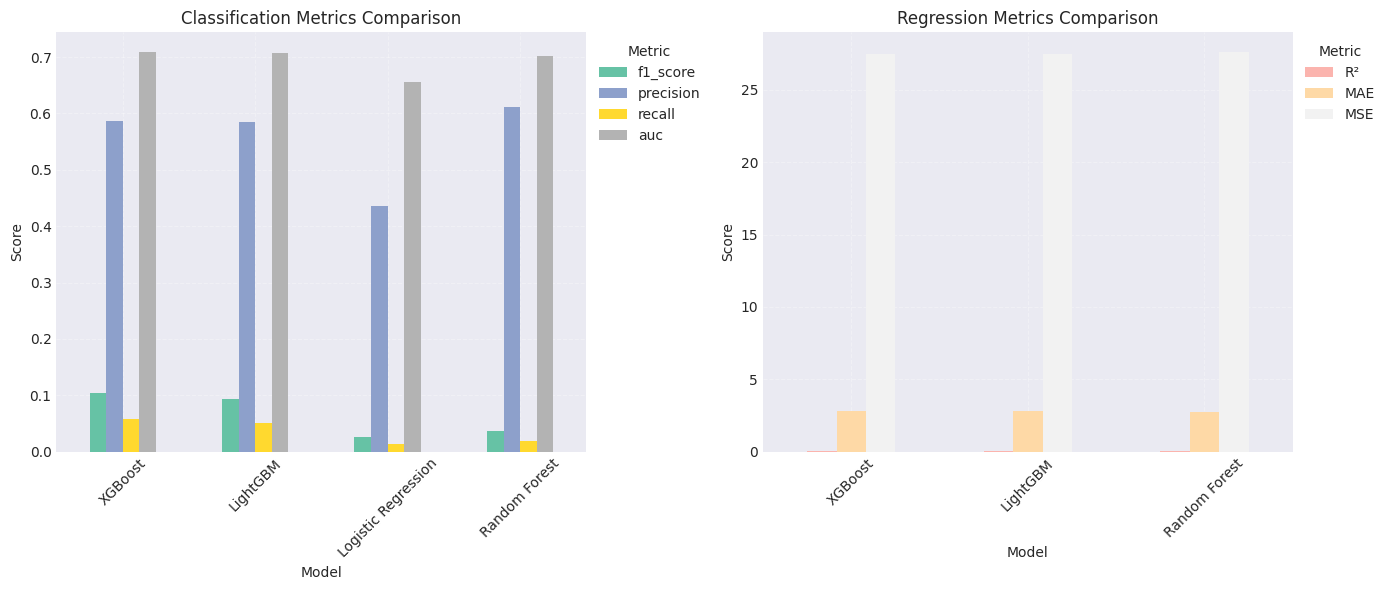

In [24]:
# Create classification metrics dataframe from cv_results
clf_metrics_data = []
for model_name, metrics in cv_results.items():
    clf_metrics_data.append({
        'Model': model_name,
        'f1_score': metrics['f1']['mean'],
        'precision': metrics['precision']['mean'],
        'recall': metrics['recall']['mean'],
        'auc': metrics['roc_auc']['mean']
    })

clf_results = pd.DataFrame(clf_metrics_data).set_index('Model')
# CLASSIFICATION METRICS
selected_clf_metrics = ['f1_score', 'precision', 'recall', 'auc']
clf_plot_data = clf_results[selected_clf_metrics].copy()
clf_plot_data.index.name = 'Model'

# REGRESSION METRICS
selected_reg_metrics = ['R²', 'MAE', 'MSE']
reg_plot_data = reg_results.set_index('Model')[selected_reg_metrics].copy()

# VIZ
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Classification Plot
clf_plot_data.plot(kind='bar', ax=axes[0], colormap='Set2')
axes[0].set_title('Classification Metrics Comparison')
axes[0].set_ylabel('Score')
axes[0].set_xlabel('Model')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Metric', bbox_to_anchor=(1.0, 1.0))
axes[0].grid(True, linestyle='--', alpha=0.3)

# Regression Plot
reg_plot_data.plot(kind='bar', ax=axes[1], colormap='Pastel1')
axes[1].set_title('Regression Metrics Comparison')
axes[1].set_ylabel('Score')
axes[1].set_xlabel('Model')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Metric', bbox_to_anchor=(1.0, 1.0))
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()



XGBoost Classifier Feature Importance:


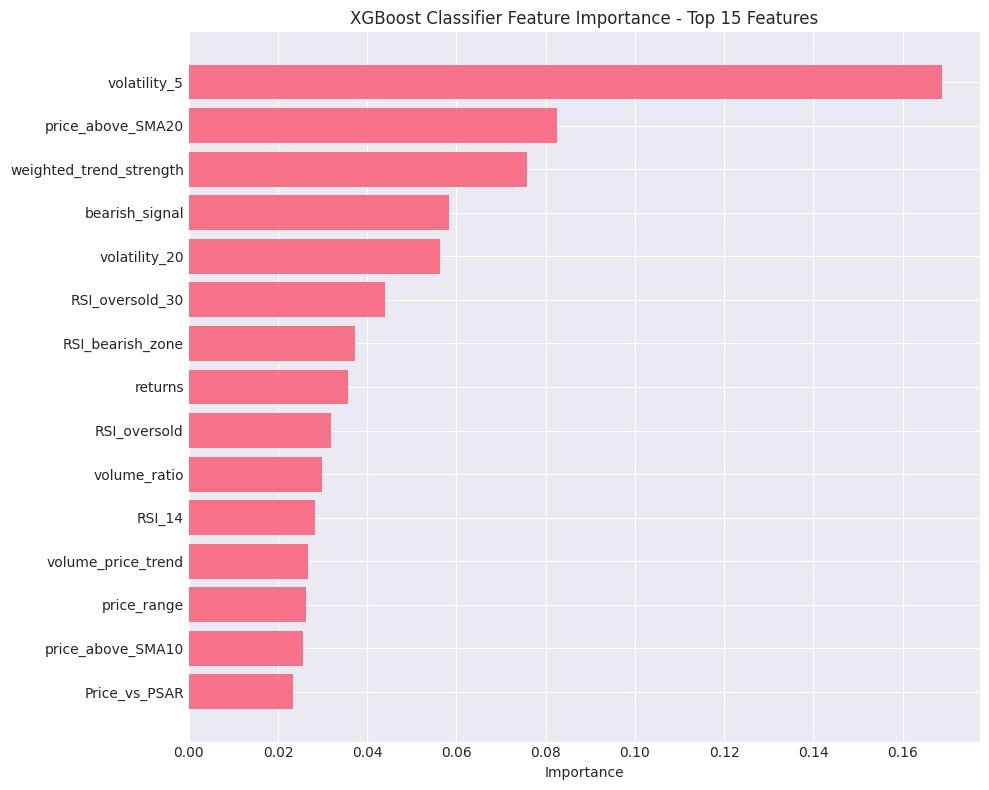

LightGBM Classifier Feature Importance:


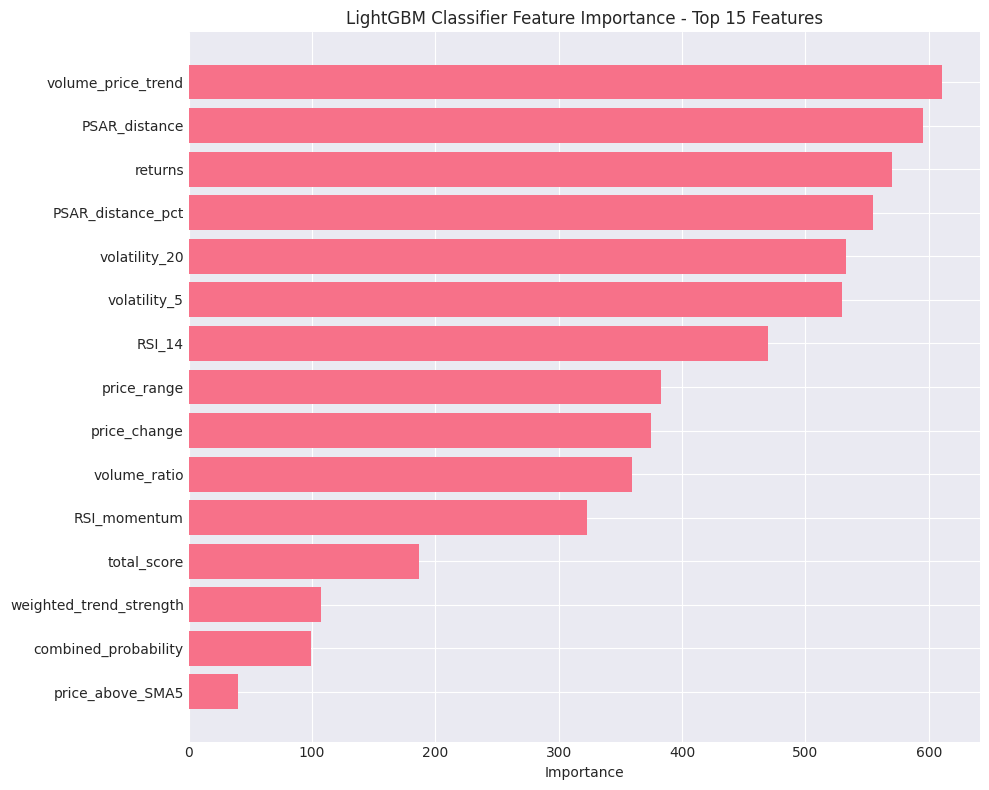


Top 10 Features - XGBoost Classifier:
                    feature  importance
19             volatility_5    0.168897
26        price_above_SMA20    0.082437
28  weighted_trend_strength    0.075907
30           bearish_signal    0.058281
20            volatility_20    0.056261
5           RSI_oversold_30    0.043922
8          RSI_bearish_zone    0.037313
21                  returns    0.035631
2              RSI_oversold    0.031839
17             volume_ratio    0.029899

Top 10 Features - LightGBM Classifier:
               feature  importance
18  volume_price_trend         611
9        PSAR_distance         595
21             returns         570
10   PSAR_distance_pct         555
20       volatility_20         533
19        volatility_5         530
0               RSI_14         470
23         price_range         383
22        price_change         375
17        volume_ratio         359


In [25]:
# Feature Importance Analysis
def plot_feature_importance(model, feature_names, title, top_n=15):
    """
    Plot feature importance cho các models
    """
    if hasattr(model, 'feature_importances_'):
        importance = model.feature_importances_
    elif hasattr(model, 'coef_'):
        importance = abs(model.coef_[0])
    else:
        return None
    
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': importance
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 8))
    top_features = feature_importance.head(top_n)
    plt.barh(range(len(top_features)), top_features['importance'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Importance')
    plt.title(f'{title} - Top {top_n} Features')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return feature_importance

# XGBoost Feature Importance
print("XGBoost Classifier Feature Importance:")
xgb_clf_importance = plot_feature_importance(
    xgb_clf, X.columns, 'XGBoost Classifier Feature Importance'
)

# LightGBM Feature Importance
print("LightGBM Classifier Feature Importance:")
lgb_clf_importance = plot_feature_importance(
    lgb_clf, X.columns, 'LightGBM Classifier Feature Importance'
)

# Display top 10 most important features
print("\nTop 10 Features - XGBoost Classifier:")
print(xgb_clf_importance.head(10))

print("\nTop 10 Features - LightGBM Classifier:")
print(lgb_clf_importance.head(10))


Using sample size: 300000 out of 1156581 total samples
Testing k=2...
k=2: Silhouette Score = 0.302
Testing k=3...
k=3: Silhouette Score = 0.305
Testing k=4...
k=4: Silhouette Score = 0.300
Testing k=5...
k=5: Silhouette Score = 0.293
Testing k=6...
k=6: Silhouette Score = 0.312
Testing k=7...
k=7: Silhouette Score = 0.316
Testing k=8...
k=8: Silhouette Score = 0.329
Testing k=9...
k=9: Silhouette Score = 0.333
Testing k=10...
k=10: Silhouette Score = 0.322


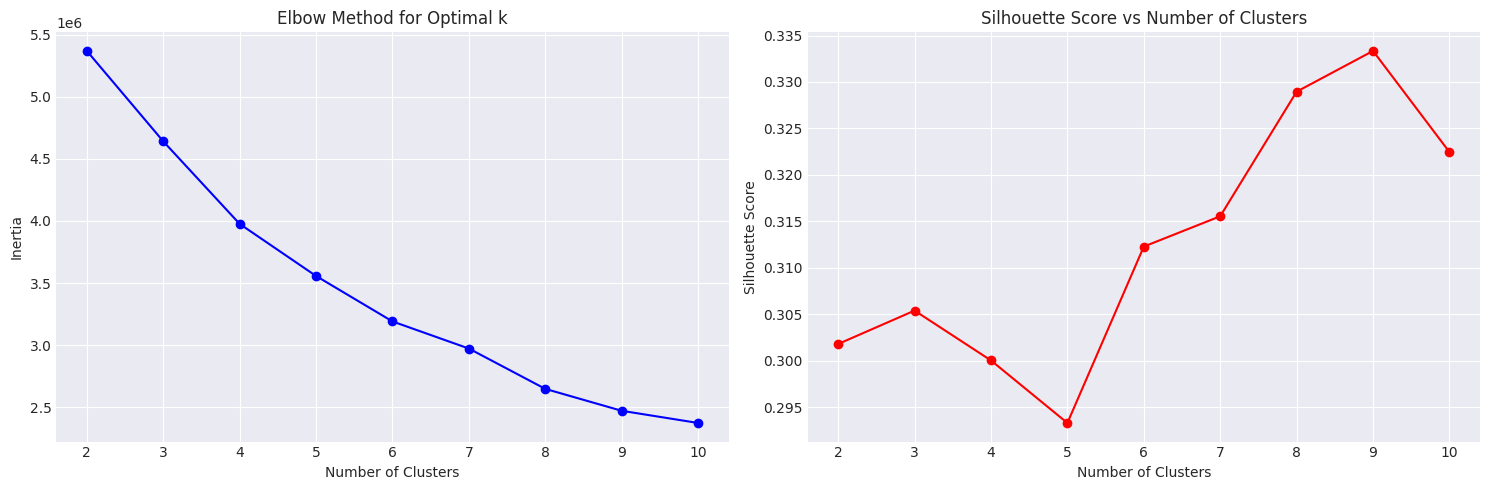

Optimal number of clusters: 9
Best silhouette score: 0.333
Applying final clustering with optimal k on full dataset...

Cluster distribution:
0    149904
1    102931
2    149343
3     30753
4    189444
5    165206
6    163416
7    174192
8     31392
Name: count, dtype: int64


In [26]:
# K-Means Clustering Analysis 
# Analyze with appropriately sized sample
max_clusters = 10  
inertias = []
silhouette_scores = []

# Use reasonable sample size to balance accuracy and performance
sample_size = min(300000, len(X_pca_10))  # Use up to 100k samples
print(f"Using sample size: {sample_size} out of {len(X_pca_10)} total samples")

# Create stratified sample to maintain data distribution
np.random.seed(42)
sample_indices = np.random.choice(len(X_pca_10), size=sample_size, replace=False)
X_sample = X_pca_10[sample_indices]

for k in range(2, max_clusters + 1):
    print(f"Testing k={k}...")
    # Use sampled dataset with reasonable parameters
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(X_sample)
    
    inertias.append(kmeans.inertia_)
    
    # Calculate silhouette score on sample
    silhouette_scores.append(silhouette_score(X_sample, labels))
    print(f"k={k}: Silhouette Score = {silhouette_scores[-1]:.3f}")

# Plot Elbow Curve và Silhouette Scores
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Elbow Method
axes[0].plot(range(2, max_clusters + 1), inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method for Optimal k')
axes[0].grid(True)

# Silhouette Scores
axes[1].plot(range(2, max_clusters + 1), silhouette_scores, 'ro-')
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs Number of Clusters')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Chọn số clusters tối ưu (silhouette score cao nhất)
optimal_k = range(2, max_clusters + 1)[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters: {optimal_k}")
print(f"Best silhouette score: {max(silhouette_scores):.3f}")

# Apply K-Means với số clusters tối ưu trên toàn bộ dataset
print("Applying final clustering with optimal k on full dataset...")
kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init=10, max_iter=300)
cluster_labels = kmeans_optimal.fit_predict(X_pca_10)  # Use full dataset for final clustering

# Add cluster labels to dataframe
df_clean_copy = df_clean.copy()
df_clean_copy['cluster'] = cluster_labels

print(f"\nCluster distribution:")
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
print(cluster_counts)


Cluster characteristics:
         RSI_14         total_score         combined_probability        target_return                target_binary Price_vs_PSAR Engulfing_Signal Volume_Anomaly
           mean     std        mean     std                 mean    std          mean    std   count          mean          mean             mean           mean
cluster                                                                                                                                                         
0        52.395   9.200      50.880  14.265                0.564  0.051         0.442  5.498  149904         0.255         0.580            0.000          0.266
1        42.901   7.018      48.520  15.480                0.471  0.050        -0.205  5.827  102931         0.214         0.438            0.000          0.262
2        87.042  11.350      52.261  13.798                0.451  0.041        -0.084  6.900  149343         0.190         0.893            0.000          0.321
3        

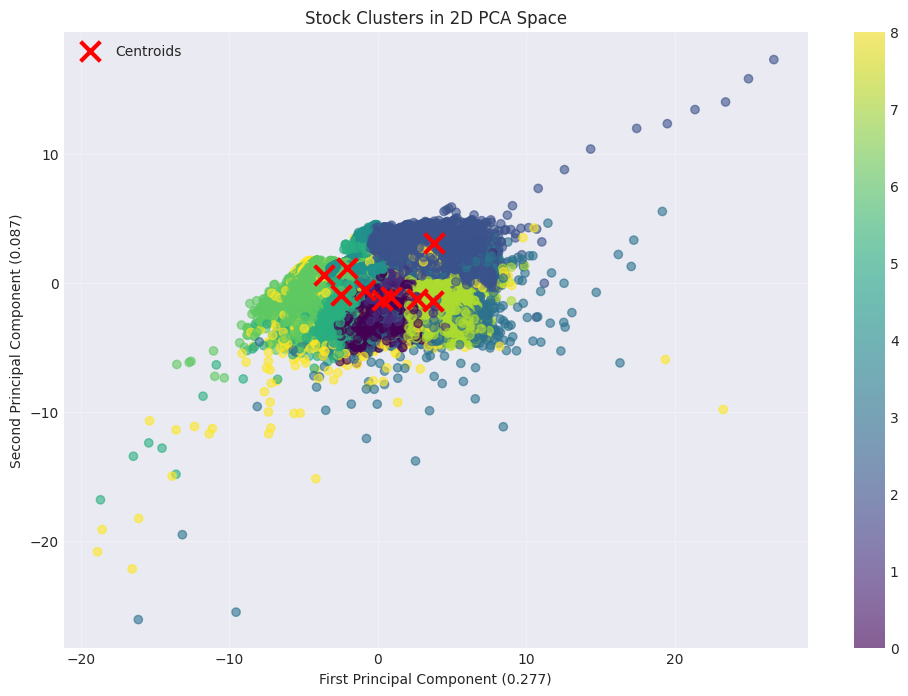

2D PCA explained variance: 0.364

Cluster Performance Analysis:
Cluster 0: Size=149904, Avg Return=0.442%, Win Rate=0.255
Cluster 1: Size=102931, Avg Return=-0.205%, Win Rate=0.214
Cluster 2: Size=149343, Avg Return=-0.084%, Win Rate=0.190
Cluster 3: Size=30753, Avg Return=-0.028%, Win Rate=0.248
Cluster 4: Size=189444, Avg Return=-0.084%, Win Rate=0.050
Cluster 5: Size=165206, Avg Return=0.535%, Win Rate=0.277
Cluster 6: Size=163416, Avg Return=0.247%, Win Rate=0.243
Cluster 7: Size=174192, Avg Return=-0.413%, Win Rate=0.206
Cluster 8: Size=31392, Avg Return=-0.085%, Win Rate=0.276


In [27]:
# Phân tích đặc điểm của từng cluster
cluster_analysis = df_clean_copy.groupby('cluster').agg({
    'RSI_14': ['mean', 'std'],
    'total_score': ['mean', 'std'],
    'combined_probability': ['mean', 'std'],
    'target_return': ['mean', 'std', 'count'],
    'target_binary': 'mean',
    'Price_vs_PSAR': 'mean',
    'Engulfing_Signal': 'mean',
    'Volume_Anomaly': 'mean'
})

print("Cluster characteristics:")
print(cluster_analysis.round(3))

# Visualize clusters in 2D PCA space
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
                     c=cluster_labels, cmap='viridis', alpha=0.6)
plt.colorbar(scatter)
plt.xlabel(f'First Principal Component ({pca_2d.explained_variance_ratio_[0]:.3f})')
plt.ylabel(f'Second Principal Component ({pca_2d.explained_variance_ratio_[1]:.3f})')
plt.title('Stock Clusters in 2D PCA Space')

# Add cluster centers in 2D space

centers_scaled = kmeans_optimal.cluster_centers_  
centers_2d = []
for i in range(optimal_k):
    cluster_mask = cluster_labels == i
    center_2d = X_pca_2d[cluster_mask].mean(axis=0)
    centers_2d.append(center_2d)
centers_2d = np.array(centers_2d)

plt.scatter(centers_2d[:, 0], centers_2d[:, 1], 
           c='red', marker='x', s=200, linewidths=3, label='Centroids')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"2D PCA explained variance: {pca_2d.explained_variance_ratio_.sum():.3f}")

# Cluster performance analysis
print("\nCluster Performance Analysis:")
for cluster_id in sorted(df_clean_copy['cluster'].unique()):
    cluster_data = df_clean_copy[df_clean_copy['cluster'] == cluster_id]
    avg_return = cluster_data['target_return'].mean()
    win_rate = cluster_data['target_binary'].mean()
    size = len(cluster_data)
    
    print(f"Cluster {cluster_id}: Size={size}, Avg Return={avg_return:.3f}%, Win Rate={win_rate:.3f}")


In [28]:
# Enhanced Ensemble Model với comprehensive metrics
print("Creating enhanced ensemble model...")

# Tạo Voting Classifier từ các models tốt nhất
voting_clf = VotingClassifier(
    estimators=[
        ('xgb', xgb_clf),
        ('lgb', lgb_clf),
        ('rf', rf_clf)
    ],
    voting='soft'  # Sử dụng probability voting
)

voting_clf.fit(X_train, y_clf_train)

# Evaluate ensemble với comprehensive metrics
ensemble_pred = voting_clf.predict(X_test)
ensemble_proba = voting_clf.predict_proba(X_test)[:, 1]

# Tính tất cả metrics cho ensemble
ensemble_metrics = calculate_comprehensive_metrics(y_clf_test, ensemble_pred, ensemble_proba)

print("ENSEMBLE MODEL COMPREHENSIVE METRICS:")
for metric, value in ensemble_metrics.items():
    print(f"{metric.upper()}: {value:.4f}")

# Enhanced comparison với tất cả metrics
enhanced_comparison = clf_results_comprehensive.copy()
ensemble_series = pd.Series(ensemble_metrics, name='Ensemble')
enhanced_comparison = pd.concat([enhanced_comparison, ensemble_series.to_frame().T])

print("\nFINAL MODEL COMPARISON WITH ENSEMBLE:")
print("="*80)
print(enhanced_comparison.sort_values('f1_score', ascending=False))

# Trading-specific analysis cho ensemble
ensemble_cm = confusion_matrix(y_clf_test, ensemble_pred)
tn, fp, fn, tp = ensemble_cm.ravel()

ensemble_trading_metrics = {
    'Signal_Accuracy': tp / (tp + fp) if (tp + fp) > 0 else 0,
    'Opportunity_Capture': tp / (tp + fn) if (tp + fn) > 0 else 0,
    'False_Signal_Rate': fp / (fp + tn) if (fp + tn) > 0 else 0,
    'NPV': tn / (tn + fn) if (tn + fn) > 0 else 0
}

print(f"\nENSEMBLE TRADING METRICS:")
for metric, value in ensemble_trading_metrics.items():
    print(f"{metric}: {value:.4f}")

# Final recommendation
print(f"\nFINAL RECOMMENDATIONS BASED ON COMPREHENSIVE METRICS:")
print("="*80)

# Model rankings by different criteria
best_f1 = enhanced_comparison.sort_values('f1_score', ascending=False).index[0]
best_precision = enhanced_comparison.sort_values('precision', ascending=False).index[0]
best_recall = enhanced_comparison.sort_values('recall', ascending=False).index[0]
best_auc = enhanced_comparison.sort_values('auc', ascending=False).index[0]

print(f"Best F1 Score (Overall Balance): {best_f1} ({enhanced_comparison.loc[best_f1, 'f1_score']:.4f})")
print(f"Best Precision (Signal Accuracy): {best_precision} ({enhanced_comparison.loc[best_precision, 'precision']:.4f})")
print(f"Best Recall (Opportunity Capture): {best_recall} ({enhanced_comparison.loc[best_recall, 'recall']:.4f})")
print(f"Best AUC (Discriminative Power): {best_auc} ({enhanced_comparison.loc[best_auc, 'auc']:.4f})")

print(f"\nTRADING STRATEGY RECOMMENDATIONS:")
print("- For CONSERVATIVE trading: Choose model with highest Precision")
print("- For AGGRESSIVE trading: Choose model with highest Recall")  
print("- For BALANCED trading: Choose model with highest F1 Score")
print("- For RISK ASSESSMENT: Choose model with highest AUC")

# Tính overall score
weights = {'f1_score': 0.3, 'precision': 0.25, 'recall': 0.25, 'auc': 0.2}
overall_scores = {}
for model in enhanced_comparison.index:
    score = sum(enhanced_comparison.loc[model, metric] * weight 
               for metric, weight in weights.items())
    overall_scores[model] = score

best_overall = max(overall_scores, key=overall_scores.get)
print(f"\nOVERALL BEST MODEL: {best_overall}")
print(f"Overall weighted score: {overall_scores[best_overall]:.4f}")


Creating enhanced ensemble model...
ENSEMBLE MODEL COMPREHENSIVE METRICS:
ACCURACY: 0.8220
PRECISION: 0.5879
RECALL: 0.0276
F1_SCORE: 0.0528
SPECIFICITY: 0.9958
BALANCED_ACCURACY: 0.5117
MATTHEWS_CORRCOEF: 0.0981
COHEN_KAPPA: 0.0373
AUC: 0.7110

FINAL MODEL COMPARISON WITH ENSEMBLE:
                     accuracy  precision    recall  f1_score  specificity  balanced_accuracy  matthews_corrcoef  cohen_kappa       auc
KNN                  0.768300   0.248900  0.143900  0.182400     0.905000           0.524400           0.061500     0.058500  0.593200
XGBoost              0.822500   0.579400  0.040300  0.075300     0.993600           0.516900           0.117100     0.053200  0.710600
LightGBM             0.822100   0.573300  0.036100  0.067900     0.994100           0.515100           0.109700     0.047600  0.710000
Ensemble             0.821962   0.587858  0.027626  0.052773     0.995762           0.511694           0.098141     0.037257  0.711003
Logistic Regression  0.819700   0.422900 

In [29]:
# MLEnhancedStockSelector

class MLEnhancedStockSelector:
    """
    ML Stock Selector (Adjusted)
    - Căn thẳng features theo scaler.feature_names_in_
    - Tính final_score (ưu tiên ML + exp.ret)
    - Chọn theo phân vị ngày (adaptive) + min_score
    - Risk filters khớp backtest (RSI≥50,<75, optional close>PSAR)
    - Fallback: nếu quá gắt -> nới ngưỡng theo phân vị/proba/TOP score
    - Risk management: 2% rule + dynamic sizing tận dụng NAV
    """

    def __init__(self, ensemble_model, xgb_regressor, scaler, filter_system=None, feature_columns=None):
        self.ensemble_clf = ensemble_model
        self.xgb_reg = xgb_regressor
        self.scaler = scaler
        self.filter_system = filter_system

        if feature_columns is not None:
            self.feature_columns = list(feature_columns)
        elif hasattr(self.scaler, "feature_names_in_"):
            self.feature_columns = list(self.scaler.feature_names_in_)
        else:
            self.feature_columns = [
                'RSI_14','RSI_momentum','RSI_oversold','RSI_overbought','RSI_neutral',
                'PSAR_distance','PSAR_distance_pct','Price_vs_PSAR','PSAR_trend_change',
                'Engulfing_Signal','Volume_Anomaly','volume_ratio','volume_price_trend',
                'volatility_5','volatility_20','returns','price_change','price_range',
                'price_above_SMA5','price_above_SMA10','price_above_SMA20','trend_strength',
                'bullish_signal','bearish_signal','total_score','combined_probability'
            ]

    # ---------- utils ---------- #
    @staticmethod
    def _ensure_numeric(df, cols):
        for c in cols:
            if c in df.columns:
                df[c] = pd.to_numeric(df[c], errors='coerce')
        return df

    @staticmethod
    def _clean_numeric(X):
        for c in X.columns:
            X[c] = pd.to_numeric(X[c], errors='coerce').replace([np.inf, -np.inf], np.nan).fillna(0)
        return X

    def _align_features(self, df_feat):
        df_feat = df_feat.copy()
        for c in self.feature_columns:
            if c not in df_feat.columns:
                df_feat[c] = 0
        X = df_feat[self.feature_columns].copy()
        X = self._clean_numeric(X)
        return X

    # ---------- scoring ---------- #
    def score_stocks(self, df, date=None):
        if df is None or len(df) == 0:
            return pd.DataFrame()
        if date is not None:
            date = pd.to_datetime(date)
            df_day = df[df['timestamp'] == date].copy()
        else:
            df_day = df.copy()
        if len(df_day) == 0:
            return pd.DataFrame()

        df_day = self._ensure_numeric(df_day, self.feature_columns)
        for col in ['ticker','timestamp','exchange','close','RSI_14','PSAR_Value']:
            if col not in df_day.columns:
                df_day[col] = np.nan
        df_day = df_day.dropna(subset=['ticker','close'])

        X_features = self._align_features(df_day)
        X_scaled = self.scaler.transform(X_features)

        if hasattr(self.ensemble_clf, "predict_proba"):
            buy_probability = self.ensemble_clf.predict_proba(X_scaled)[:, 1]
        else:
            buy_probability = self.ensemble_clf.predict(X_scaled).astype(float)

        try:
            expected_return = self.xgb_reg.predict(X_scaled)
        except Exception:
            expected_return = np.zeros(len(df_day), dtype=float)

        traditional_score = df_day['total_score'].to_numpy(copy=False) if 'total_score' in df_day.columns else np.zeros(len(df_day))
        traditional_prob  = df_day['combined_probability'].to_numpy(copy=False) if 'combined_probability' in df_day.columns else np.zeros(len(df_day))

        final_score = (
            buy_probability * 0.5 +
            (traditional_score / 100.0) * 0.2 +
            traditional_prob * 0.2 +
            np.clip(expected_return / 5.0, -0.5, 0.5) * 0.1
        )

        base_cols = [c for c in ['ticker','timestamp','exchange','close','RSI_14','PSAR_Value'] if c in df_day.columns]
        results = df_day[base_cols].copy()
        results['ml_buy_probability']      = buy_probability
        results['ml_expected_return']      = expected_return
        results['traditional_score']       = traditional_score
        results['traditional_probability'] = traditional_prob
        results['final_score']             = final_score

        for flag in ['condition_strong_buy','condition_buy']:
            results[flag] = df_day[flag].values if flag in df_day.columns else 0

        return results.sort_values('final_score', ascending=False).reset_index(drop=True)

    # ---------- selection (adaptive + fallback) ---------- #
    def select_top_stocks(
        self, df, date=None, top_n=20, min_score=0.50, risk_filters=True,
        max_positions=10, quantile_cut=0.88, require_pos_expret=False
    ):
        scored = self.score_stocks(df, date=date)
        if len(scored) == 0:
            return pd.DataFrame()

        q = float(scored['final_score'].quantile(quantile_cut))
        eff_min = max(float(min_score), q)
        filtered = scored[scored['final_score'] >= eff_min].copy()

        if risk_filters and len(filtered) > 0:
            cond = (
                (filtered['RSI_14'] >= 50) & (filtered['RSI_14'] < 75) &
                (filtered['ml_buy_probability'] > 0.40) &
                (filtered['traditional_probability'] > 0.40)
            )
            if 'PSAR_Value' in filtered.columns:
                cond = cond & (filtered['close'] > filtered['PSAR_Value'])
            if require_pos_expret:
                cond = cond & (filtered['ml_expected_return'] > 0.0)
            filtered = filtered[cond]

            # Fallback cấp 1: nới proba theo phân vị 60% trong-ngày
            if len(filtered) == 0:
                p_cut = max(0.40, float(scored['ml_buy_probability'].quantile(0.60)))
                cond2 = (
                    (scored['final_score'] >= eff_min) &
                    (scored['RSI_14'] >= 50) & (scored['RSI_14'] < 75) &
                    (scored['ml_buy_probability'] > p_cut)
                )
                if 'PSAR_Value' in scored.columns:
                    cond2 = cond2 & (scored['close'] > scored['PSAR_Value'])
                if require_pos_expret:
                    cond2 = cond2 & (scored['ml_expected_return'] > 0.0)
                filtered = scored[cond2].copy()

            # Fallback cấp 2: vẫn rỗng -> chỉ dùng eff_min
            if len(filtered) == 0:
                filtered = scored[scored['final_score'] >= eff_min].copy()

        elif not risk_filters:
            filtered = filtered[(filtered['RSI_14'] > 20) & (filtered['RSI_14'] < 80)]

        if self.filter_system is not None and len(filtered) > 0:
            try:
                filtered = self.filter_system.apply(filtered)
            except Exception:
                pass

        cap = min(int(top_n), int(max_positions), 10)
        filtered = filtered.sort_values('final_score', ascending=False).head(cap).copy()
        filtered['ML_Selected'] = 1
        return filtered.reset_index(drop=True)

    # ---------- risk management ---------- #
    @staticmethod
    def calculate_position_value(portfolio_value, risk_per_trade=0.02, stop_loss_pct=0.08):
        return portfolio_value * float(risk_per_trade) / float(stop_loss_pct)

    def apply_risk_management(
        self, selected_stocks, portfolio_value=1_000_000,
        risk_per_trade=0.02, stop_loss_pct=0.08, take_profit_pct=0.15,
        target_utilization=0.90
    ):
        if selected_stocks is None or len(selected_stocks) == 0:
            return selected_stocks

        df = selected_stocks.copy()
        if 'close' not in df.columns:
            return df
        df = df[df['close'] > 0].copy()

        # base sizing
        pv_each = self.calculate_position_value(
            portfolio_value=portfolio_value,
            risk_per_trade=risk_per_trade,
            stop_loss_pct=stop_loss_pct
        )
        df['position_value']  = float(pv_each)
        df['position_shares'] = df['position_value'] / df['close']

        # downscale if > NAV
        total_alloc = df['position_value'].sum()
        if total_alloc > portfolio_value and total_alloc > 0:
            scale = portfolio_value / total_alloc
            df['position_value']  *= scale
            df['position_shares'] *= scale
            total_alloc = df['position_value'].sum()

        # dynamic up-scale to target utilization
        target_alloc = float(target_utilization) * portfolio_value
        if total_alloc < target_alloc and total_alloc > 0:
            scale = min(target_alloc / total_alloc, portfolio_value / total_alloc)
            df['position_value']  *= scale
            df['position_shares'] *= scale

        df['stop_loss_price']     = df['close'] * (1 - float(stop_loss_pct))
        df['take_profit_price']   = df['close'] * (1 + float(take_profit_pct))
        df['trailing_sl_trigger'] = df['close'] * (1 + 0.09)
        return df.reset_index(drop=True)

# Khởi tạo (sau khi đã có voting_clf, xgb_reg, scaler, df_clean_copy)
df_clean_copy['timestamp'] = pd.to_datetime(df_clean_copy['timestamp'])
ml_selector = MLEnhancedStockSelector(
    ensemble_model=voting_clf,
    xgb_regressor=xgb_reg,
    scaler=scaler,
    filter_system=filter_system,   # hoặc None
    feature_columns=None
)
print("ML-Enhanced Stock Selector initialized")


ML-Enhanced Stock Selector initialized


In [30]:
# TEST
TEST_DATES = ['2024-01-15', '2024-02-01', '2024-02-15']
PORTFOLIO_VALUE = 1_000_000
TOP_N = 10
MIN_SCORE = 0.50          
QUANTILE_CUT = 0.88       
RISK_FILTERS = True
REQUIRE_POS_EXP_RET = False

df_clean_copy['timestamp'] = pd.to_datetime(df_clean_copy['timestamp'])

def print_block_title(title):
    print("\n" + "="*len(title))
    print(title)
    print("="*len(title))

def summarize_selected(df, portfolio_value):
    if df is None or len(df) == 0:
        print("No stocks selected.")
        return
    cols_show = [c for c in [
        'ticker','exchange','close','RSI_14','final_score',
        'ml_buy_probability','traditional_probability','ml_expected_return',
        'position_shares','position_value','stop_loss_price','take_profit_price'
    ] if c in df.columns]
    print(df[cols_show].round(4))
    print("\nSummary Statistics:")
    if 'ml_buy_probability' in df.columns:
        print(f"- Avg ML Buy Probability: {df['ml_buy_probability'].mean():.3f}")
    if 'traditional_probability' in df.columns:
        print(f"- Avg Traditional Probability: {df['traditional_probability'].mean():.3f}")
    if 'ml_expected_return' in df.columns:
        print(f"- Avg Expected Return: {df['ml_expected_return'].mean():.3f}%")
    if 'final_score' in df.columns:
        print(f"- Avg Final Score: {df['final_score'].mean():.3f}")
    if 'position_value' in df.columns:
        total_alloc = df['position_value'].sum()
        print(f"- Total Portfolio Allocation: {total_alloc:,.0f} VND  ({total_alloc/portfolio_value*100:.1f}%)")

def debug_filters(date):
    scored = ml_selector.score_stocks(df_clean_copy, date=date)
    print(f"Scored rows: {len(scored)}")
    if len(scored) == 0:
        print("→ Không có dòng nào được score.")
        return
    print("Quantiles(final_score):",
          scored['final_score'].quantile([.8,.85,.9,.92,.95,.98]).round(4).to_dict())
    print("Top 5 by final_score:")
    print(scored[['ticker','final_score','RSI_14','ml_buy_probability',
                  'traditional_probability','ml_expected_return']].head(5).round(4))

for d in TEST_DATES:
    print_block_title(f"[{d}] Pick top {TOP_N} (min_score={MIN_SCORE}, q={QUANTILE_CUT})")
    debug_filters(d)

    try:
        picked = ml_selector.select_top_stocks(
            df_clean_copy, date=d, top_n=TOP_N,
            min_score=MIN_SCORE, risk_filters=RISK_FILTERS,
            max_positions=10, quantile_cut=QUANTILE_CUT,
            require_pos_expret=REQUIRE_POS_EXP_RET
        )
    except TypeError:
        picked = ml_selector.select_top_stocks(
            df_clean_copy, date=d, top_n=TOP_N,
            min_score=MIN_SCORE, risk_filters=RISK_FILTERS
        )

    if len(picked) == 0:
        print("No stocks selected with risk filters ON.")
        continue

    try:
        picked_risk = ml_selector.apply_risk_management(
            picked, portfolio_value=PORTFOLIO_VALUE,
            risk_per_trade=0.02, stop_loss_pct=0.08, take_profit_pct=0.15,
            target_utilization=0.90
        )
    except Exception as e:
        print(f"apply_risk_management failed: {e}")
        picked_risk = picked.copy()

    print("\n>> Selected (with risk filters, adaptive) + Risk Management applied:")
    summarize_selected(picked_risk, PORTFOLIO_VALUE)

print("ML-Enhanced Stock Selector test completed.")



[2024-01-15] Pick top 10 (min_score=0.5, q=0.88)
Scored rows: 1564
Quantiles(final_score): {0.8: 0.3473, 0.85: 0.3625, 0.9: 0.3868, 0.92: 0.3995, 0.95: 0.424, 0.98: 0.4555}
Top 5 by final_score:
  ticker  final_score   RSI_14  ml_buy_probability  traditional_probability  ml_expected_return
0    BVN       0.5531  50.0000              0.4522                   0.6475              4.6958
1    MTG       0.5394  42.6921              0.5698                   0.5050              3.3010
2    HNA       0.5177  61.6638              0.3592                   0.6475              1.9323
3    KTT       0.5145  77.7778              0.4380                   0.5075              5.6317
4    VE3       0.5121  58.9041              0.4382                   0.6275              2.7308

>> Selected (with risk filters, adaptive) + Risk Management applied:
  ticker exchange    close   RSI_14  final_score  ml_buy_probability  traditional_probability  ml_expected_return  position_shares  position_value  stop_loss_

# 5.BACKTEST 
- Áp dụng chiến lược trên dữ liệu lịch sử từ 2022-2024
- Tính toán các chỉ số hiệu suất: Returns, Win Rate, Max Drawdown, Sharpe Ratio
- So sánh với benchmark VN-Index 

In [31]:
# Import thư viện và đọc dữ liệu
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Đọc dữ liệu đã được xử lý
df = pd.read_csv('vietnam_stocks_data.csv')

# Chuyển đổi cột timestamp thành datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])


In [32]:
# Chuẩn bị dữ liệu + tạo tín hiệu giao dịch cho backtest
def prepare_trading_signals(df: pd.DataFrame) -> pd.DataFrame:
    required_cols = [
        'close','volume','ticker',
        'RSI_14','PSAR_Value','Price_vs_PSAR',
        'Volume_Anomaly','Engulfing_Signal','Engulfing_In_3_Candles'
    ]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Thiếu cột bắt buộc trong df: {missing}")

    df_sig = df.copy()

    # Chuẩn hóa timestamp
    if 'timestamp' not in df_sig.columns:
        if 'time' in df_sig.columns:
            df_sig['timestamp'] = pd.to_datetime(df_sig['time'])
        elif 'date' in df_sig.columns:
            df_sig['timestamp'] = pd.to_datetime(df_sig['date'])
        elif isinstance(df_sig.index, pd.DatetimeIndex):
            df_sig['timestamp'] = df_sig.index
        else:
            df_sig['timestamp'] = pd.to_datetime(pd.Series(range(len(df_sig)), index=df_sig.index), unit='D', origin='unix')

    # EMA 20
    if 'ema_20' not in df_sig.columns:
        df_sig['ema_20'] = df_sig.groupby('ticker')['close'].transform(lambda x: x.ewm(span=20, min_periods=1).mean())

    df_sig = df_sig.dropna(subset=['RSI_14', 'PSAR_Value', 'ema_20'])

    # Entry flags
    df_sig['price_above_psar'] = (df_sig['Price_vs_PSAR'] == 1).astype(int)
    df_sig['rsi_above_50'] = (df_sig['RSI_14'] > 50).astype(int)
    df_sig['volume_confirmation'] = df_sig['Volume_Anomaly'].astype(int)

    if set(df_sig['Engulfing_In_3_Candles'].dropna().unique()).issubset({0,1}):
        df_sig['bullish_engulfing_recent'] = df_sig['Engulfing_In_3_Candles'].astype(int)
    else:
        df_sig['bullish_engulfing_recent'] = (
            df_sig['Engulfing_Signal'].rolling(window=3, min_periods=1).max().fillna(0) == 1
        ).astype(int)

    df_sig['bearish_engulfing'] = (df_sig['Engulfing_Signal'] == -1).astype(int)

    # Entry signals
    df_sig['basic_long_entry'] = (
        (df_sig['price_above_psar'] == 1) &
        (df_sig['rsi_above_50'] == 1)
    ).astype(int)

    df_sig['enhanced_long_entry'] = (
        (df_sig['basic_long_entry'] == 1) &
        (df_sig['volume_confirmation'] == 1) &
        (df_sig['bullish_engulfing_recent'] == 1)
    ).astype(int)

    # Exit signals
    df_sig['long_exit_rsi'] = (df_sig['RSI_14'] < 50).astype(int)
    df_sig['long_exit_engulfing'] = df_sig['bearish_engulfing']
    df_sig['basic_long_exit'] = (
        (df_sig['long_exit_rsi'] == 1) | (df_sig['long_exit_engulfing'] == 1)
    ).astype(int)

    # Entry hợp nhất + cho multi chiến lược
    df_sig['long_entry'] = np.where(df_sig['enhanced_long_entry'] == 1, 2, df_sig['basic_long_entry'])
    df_sig['multi_strategy_entry'] = df_sig['long_entry']

    df_sig.sort_values(['ticker','timestamp'], inplace=True, ignore_index=True)
    return df_sig



# === Chạy tạo tín hiệu & thống kê nhanh ===
print("Đang tính toán tín hiệu giao dịch...")
df_with_signals = prepare_trading_signals(df)

print("\nThống kê tín hiệu giao dịch:")
print(f"- Tín hiệu mua cơ bản      : {int(df_with_signals['basic_long_entry'].sum()):,}")
print(f"- Tín hiệu mua nâng cao     : {int(df_with_signals['enhanced_long_entry'].sum()):,}")
print(f"- Tín hiệu bán (RSI < 50)   : {int(df_with_signals['long_exit_rsi'].sum()):,}")
print(f"- Tín hiệu bán (Bearish Eng): {int(df_with_signals['long_exit_engulfing'].sum()):,}")

# Hiển thị một vài mẫu tín hiệu mua cơ bản
print("\nMẫu tín hiệu mua cơ bản:")
cols_show = [c for c in ['ticker','timestamp','close','RSI_14','PSAR_Value','volume'] if c in df_with_signals.columns]
buy_samples = (df_with_signals[df_with_signals['basic_long_entry'] == 1]
               .sort_values('timestamp', ascending=False)
               [cols_show]
               .head(10))
print(buy_samples.to_string(index=False))


Đang tính toán tín hiệu giao dịch...

Thống kê tín hiệu giao dịch:
- Tín hiệu mua cơ bản      : 329,566
- Tín hiệu mua nâng cao     : 21,065
- Tín hiệu bán (RSI < 50)   : 490,441
- Tín hiệu bán (Bearish Eng): 30,349

Mẫu tín hiệu mua cơ bản:
ticker  timestamp      close     RSI_14   PSAR_Value   volume
   SGI 2024-12-31 12596.0000  55.027954 12173.470795   2300.0
   NNT 2024-12-31 51648.2400 100.000000 49710.620314      0.0
   MCF 2024-12-31  8042.2800 100.000000  7556.617331   1000.0
   PFL 2024-12-31  2143.0000  68.571429  1936.889600  12100.0
   TDW 2024-12-31 49991.1300  52.702703 47842.926290    200.0
   ILS 2024-12-31 13193.0000  50.435540 12419.520000   3000.0
   TMT 2024-12-31  9840.0000  86.263736  6902.127923 271950.0
   MCG 2024-12-31  1901.0000  59.960938  1606.000000  73100.0
   TTN 2024-12-31 21840.8988  71.642658 20050.440371 433900.0
   G20 2024-12-31   600.0000  86.231884   419.215841      0.0


In [33]:
# Backtest
class TradingBacktester:
    def __init__(self,
                 initial_capital: float = 1_000_000,
                 position_size_pct: float = 0.02,
                 take_profit: float = 0.15,
                 stop_loss: float = 0.05,
                 max_positions: int = 10,
                 fee_rate: float = 0.001,
                 max_holding_days: int = 10):

        self.initial_capital = float(initial_capital)
        self.current_capital = float(initial_capital)
        self.position_size_pct = float(position_size_pct)
        self.take_profit = float(take_profit)
        self.stop_loss = float(stop_loss)
        self.max_positions = int(max_positions)
        self.fee_rate = float(fee_rate)
        self.max_holding_days = int(max_holding_days)

        self.trades = []
        self.active_positions = {}
        self.daily_portfolio_value = []
        self._last_price_by_ticker = {}

    def calculate_position_size(self, price: float, rsi: float) -> int:
        if price <= 0: return 0
        factor = 1 + (rsi - 50)/100  # tăng tỷ trọng nếu RSI cao
        factor = np.clip(factor, 0.5, 2.0)
        position_value = self.current_capital * self.position_size_pct * factor
        shares = int(position_value // price)
        return max(shares, 100)

    def _update_last_price_cache(self, ticker: str, price: float):
        self._last_price_by_ticker[ticker] = float(price)

    def process_trade_signals(self, df_signals: pd.DataFrame):
        required_cols = {'ticker','timestamp','close','volume','multi_strategy_entry','basic_long_exit','ema_20','RSI_14'}
        missing = required_cols - set(df_signals.columns)
        if missing:
            raise ValueError(f"Thiếu cột trong df_signals: {sorted(missing)}")

        df = df_signals.copy()
        df = df[(df['volume'] > 5000) & (df['close'] > df['ema_20']) & (df['RSI_14'] > 40)]
        df.sort_values(['timestamp','ticker'], inplace=True)
        df.reset_index(drop=True, inplace=True)

        prev_date = None
        for _, row in df.iterrows():
            ticker = row['ticker']
            ts = pd.to_datetime(row['timestamp'])
            price = float(row['close'])
            rsi = float(row['RSI_14'])

            self._update_last_price_cache(ticker, price)
            self.update_active_positions(row)

            if row['multi_strategy_entry'] == 1 and len(self.active_positions) < self.max_positions:
                if ticker not in self.active_positions:
                    self.open_position(row, rsi)

            cur_date = ts.date()
            if prev_date is None or cur_date != prev_date:
                nav = self.calculate_portfolio_value()
                self.daily_portfolio_value.append({
                    'date': cur_date,
                    'portfolio_value': nav,
                    'active_positions': len(self.active_positions),
                    'cash': self.current_capital
                })
                prev_date = cur_date

        self.close_all_positions(df)

    def open_position(self, row: pd.Series, rsi: float):
        ticker = row['ticker']
        entry_price = float(row['close'])
        entry_date = pd.to_datetime(row['timestamp'])

        shares = self.calculate_position_size(entry_price, rsi)
        if shares <= 0: return

        entry_value = shares * entry_price
        fee_buy = entry_value * self.fee_rate
        total_cost = entry_value + fee_buy

        if total_cost <= self.current_capital * 0.8:
            self.active_positions[ticker] = {
                'entry_date': entry_date,
                'entry_price': entry_price,
                'position_size': shares,
                'entry_fee': fee_buy,
                'max_price': entry_price,
                'partial_exit': False
            }
            self.current_capital -= total_cost

    def update_active_positions(self, row: pd.Series):
        ticker = row['ticker']
        if ticker not in self.active_positions: return

        pos = self.active_positions[ticker]
        current_price = float(row['close'])
        entry_price = pos['entry_price']
        pos['max_price'] = max(pos['max_price'], current_price)

        pct_change = (current_price - entry_price) / entry_price
        holding_days = (pd.to_datetime(row['timestamp']) - pos['entry_date']).days

        if not pos['partial_exit'] and pct_change >= 0.05:
            exit_value = current_price * (pos['position_size']//2)
            fee_sell = exit_value * self.fee_rate
            self.current_capital += (exit_value - fee_sell)
            pos['position_size'] = pos['position_size']//2
            pos['partial_exit'] = True
            return

        should_close = False
        reason = ""
        if pct_change >= self.take_profit:
            should_close, reason = True, "Take Profit"
        elif pct_change <= -self.stop_loss:
            should_close, reason = True, "Stop Loss"
        elif pos['max_price'] / entry_price >= 1.05 and current_price <= pos['max_price'] * 0.97:
            should_close, reason = True, "Trailing Stop"
        elif holding_days >= self.max_holding_days:
            should_close, reason = True, "Max Holding"
        elif row['basic_long_exit'] == 1:
            should_close, reason = True, "Signal Exit"

        if should_close:
            self.close_position(ticker, current_price, pd.to_datetime(row['timestamp']), reason)

    def close_position(self, ticker: str, exit_price: float, exit_date: pd.Timestamp, reason: str):
        if ticker not in self.active_positions: return

        pos = self.active_positions[ticker]
        shares = pos['position_size']
        entry_value = pos['entry_price'] * shares
        exit_value = exit_price * shares

        fee_sell = exit_value * self.fee_rate
        fee_buy = pos['entry_fee']
        self.current_capital += (exit_value - fee_sell)

        pnl = (exit_value - fee_sell) - (entry_value + fee_buy)
        pnl_pct = pnl / (entry_value + fee_buy) if entry_value > 0 else 0.0

        self.trades.append({
            'ticker': ticker,
            'entry_date': pos['entry_date'],
            'exit_date': exit_date,
            'entry_price': pos['entry_price'],
            'exit_price': exit_price,
            'position_size': shares,
            'trade_return': pnl,
            'trade_return_pct': pnl_pct,
            'exit_reason': reason,
            'holding_days': int((exit_date - pos['entry_date']).days)
        })

        del self.active_positions[ticker]

    def close_all_positions(self, df_sorted: pd.DataFrame):
        if not self.active_positions: return
        last_rows = df_sorted.sort_values(['ticker','timestamp']).groupby('ticker').tail(1).set_index('ticker')
        for ticker in list(self.active_positions.keys()):
            if ticker in last_rows.index:
                last_row = last_rows.loc[ticker]
                self.close_position(ticker, float(last_row['close']), pd.to_datetime(last_row['timestamp']), "End of Test")

    def calculate_portfolio_value(self) -> float:
        nav = float(self.current_capital)
        for ticker, pos in self.active_positions.items():
            cur_price = self._last_price_by_ticker.get(ticker, pos['entry_price'])
            nav += pos['position_size'] * float(cur_price)
        return nav


# ===== Chạy backtest cho chiến lược cơ bản =====
print("Khởi tạo Backtest Engine...")
backtester_basic = TradingBacktester(
    initial_capital=1_000_000,
    position_size_pct=0.02,
    take_profit=0.15,
    stop_loss=0.08,
    max_positions=10,
    fee_rate=0.001
)

# Thực thi backtest
backtester_basic.process_trade_signals(df_with_signals)

# Kết quả nhanh
trades_df = pd.DataFrame(backtester_basic.trades)
print("\nTổng giao dịch khớp:", len(trades_df))
if not trades_df.empty:
    print(trades_df.head(10).to_string(index=False))

nav_df = pd.DataFrame(backtester_basic.daily_portfolio_value)
print("\nNAV cuối cùng:", nav_df.iloc[-1]['portfolio_value'] if not nav_df.empty else backtester_basic.current_capital)


Khởi tạo Backtest Engine...

Tổng giao dịch khớp: 149
ticker entry_date  exit_date  entry_price  exit_price  position_size  trade_return  trade_return_pct exit_reason  holding_days
   KHL 2022-01-21 2022-01-28       2299.0      2374.0            100       7032.70          0.030560 Signal Exit             7
   CPI 2022-01-21 2022-02-25       6694.0      6155.0            100     -55184.90         -0.082357   Stop Loss            35
   DDM 2022-02-25 2022-03-11       4809.0      6270.0             50      72255.60          0.299902 Take Profit            14
   HDO 2022-03-11 2022-03-25       2105.0      2158.0            100       4873.70          0.023130 Max Holding            14
   KHL 2022-02-11 2022-03-25       2356.0      2388.0            100       2725.60          0.011557 Max Holding            42
   KHL 2022-03-25 2022-05-27       2388.0      1843.0             50     -27580.95         -0.230535   Stop Loss            63
   HLA 2022-02-25 2022-07-15       1827.0       793.0    

In [34]:
# Chỉ số hiệu suất chiến lược
class PerformanceAnalyzer:
    def __init__(self, backtester):
        """
        Khởi tạo Performance Analyzer
        """
        self.backtester = backtester
        self.trades_df = pd.DataFrame(backtester.trades).copy()
        self.portfolio_df = pd.DataFrame(backtester.daily_portfolio_value).copy()

        # Chuẩn hóa & sắp xếp dữ liệu NAV theo ngày
        if not self.portfolio_df.empty:
            self.portfolio_df['date'] = pd.to_datetime(self.portfolio_df['date']).dt.date
            self.portfolio_df.sort_values('date', inplace=True, ignore_index=True)

    # ---- Helper ----
    def _daily_returns(self) -> pd.Series:
        if self.portfolio_df.empty or 'portfolio_value' not in self.portfolio_df.columns:
            return pd.Series(dtype=float)
        pv = pd.Series(self.portfolio_df['portfolio_value'].values,
                       index=pd.to_datetime(self.portfolio_df['date']))
        return pv.pct_change()

    def calculate_basic_metrics(self):
        """Tính toán các chỉ số hiệu suất cơ bản."""
        if self.trades_df.empty:
            return {"error": "Không có giao dịch nào được thực hiện"}

        metrics = {}
        metrics['total_trades'] = len(self.trades_df)
        metrics['initial_capital'] = float(self.backtester.initial_capital)

        # Vốn cuối kỳ: dùng current_capital (đã đóng vị thế trong Cell 3)
        metrics['final_capital'] = float(self.backtester.current_capital)

        # Tổng lợi nhuận
        total_return = (metrics['final_capital'] - metrics['initial_capital']) / metrics['initial_capital']
        metrics['total_return'] = float(total_return)
        metrics['total_return_pct'] = float(total_return * 100)

        # Win/Loss
        winning_trades = self.trades_df[self.trades_df['trade_return_pct'] > 0]
        losing_trades  = self.trades_df[self.trades_df['trade_return_pct'] < 0]
        metrics['winning_trades'] = int(len(winning_trades))
        metrics['losing_trades']  = int(len(losing_trades))
        metrics['win_rate'] = float(len(winning_trades) / len(self.trades_df)) if len(self.trades_df) else 0.0
        metrics['win_rate_pct'] = float(metrics['win_rate'] * 100)

        # Trung bình lời/lỗ (% theo trade_return_pct dạng thập phân)
        metrics['avg_win'] = float(winning_trades['trade_return_pct'].mean()) if len(winning_trades) else 0.0
        metrics['avg_loss'] = float(losing_trades['trade_return_pct'].mean()) if len(losing_trades) else 0.0
        metrics['avg_trade_return'] = float(self.trades_df['trade_return_pct'].mean())

        # Best/Worst trade (%)
        metrics['best_trade']  = float(self.trades_df['trade_return_pct'].max())
        metrics['worst_trade'] = float(self.trades_df['trade_return_pct'].min())

        # Profit Factor
        gross_profit = float(winning_trades['trade_return'].sum()) if len(winning_trades) else 0.0
        gross_loss   = float(abs(losing_trades['trade_return'].sum())) if len(losing_trades) else 0.0
        metrics['profit_factor'] = float(gross_profit / gross_loss) if gross_loss > 0 else float('inf')

        # Expectancy (kỳ vọng lợi nhuận mỗi lệnh, %)
        p_win = metrics['win_rate']
        avg_win = metrics['avg_win']
        avg_loss = metrics['avg_loss']
        metrics['expectancy_pct'] = float(p_win * avg_win + (1 - p_win) * avg_loss) * 100.0

        # Thời gian nắm giữ TB
        if 'holding_days' in self.trades_df.columns and len(self.trades_df) > 0:
            metrics['avg_holding_days'] = float(self.trades_df['holding_days'].mean())
        else:
            metrics['avg_holding_days'] = 0.0

        return metrics

    def calculate_drawdown_analysis(self):
        """Tính toán phân tích drawdown dựa trên NAV ngày."""
        if self.portfolio_df.empty or 'portfolio_value' not in self.portfolio_df.columns:
            return {"error": "Không có dữ liệu portfolio"}

        df = self.portfolio_df.copy()
        df['pv'] = df['portfolio_value'].astype(float)
        df['peak'] = df['pv'].cummax()
        df['drawdown'] = (df['pv'] / df['peak']) - 1.0
        df['drawdown_pct'] = df['drawdown'] * 100.0

        max_drawdown = float(df['drawdown'].min())
        max_drawdown_pct = max_drawdown * 100.0
        avg_drawdown = float(df.loc[df['drawdown'] < 0, 'drawdown'].mean()) if (df['drawdown'] < 0).any() else 0.0

        # Xác định các period drawdown (đơn giản theo ngưỡng)
        drawdown_periods = []
        in_dd = False
        start_date = None
        for _, r in df.iterrows():
            if r['drawdown'] < -0.01 and not in_dd:
                in_dd = True
                start_date = r['date']
            elif r['drawdown'] >= -0.001 and in_dd:
                in_dd = False
                if start_date:
                    seg = df[(pd.to_datetime(df['date']) >= pd.to_datetime(start_date)) &
                             (pd.to_datetime(df['date']) <= pd.to_datetime(r['date']))]
                    drawdown_periods.append({
                        'start_date': start_date,
                        'end_date': r['date'],
                        'duration_days': int((pd.to_datetime(r['date']) - pd.to_datetime(start_date)).days),
                        'max_drawdown_in_period': float(seg['drawdown'].min())
                    })

        return {
            'max_drawdown': max_drawdown,
            'max_drawdown_pct': max_drawdown_pct,
            'avg_drawdown': avg_drawdown,
            'drawdown_periods': drawdown_periods,
            'total_drawdown_periods': len(drawdown_periods),
            'avg_drawdown_duration': float(np.mean([p['duration_days'] for p in drawdown_periods])) if drawdown_periods else 0.0
        }

    def calculate_sharpe_ratio(self, risk_free_rate: float = 0.04):
        """
        Tính Sharpe Ratio (năm).
        risk_free_rate: lãi suất phi rủi ro năm (vd 0.04 = 4%)
        """
        rets = self._daily_returns().dropna()
        if rets.empty:
            return {"sharpe_ratio": 0.0, "annualized_return": 0.0, "annualized_volatility": 0.0, "daily_volatility": 0.0}

        # Annualized volatility từ daily returns
        daily_vol = float(rets.std())
        ann_vol = daily_vol * np.sqrt(252)

        # Annualized return từ NAV đầu/cuối
        start_val = float(self.portfolio_df.iloc[0]['portfolio_value'])
        end_val   = float(self.portfolio_df.iloc[-1]['portfolio_value'])
        n_days = max(1, int((pd.to_datetime(self.portfolio_df.iloc[-1]['date']) -
                             pd.to_datetime(self.portfolio_df.iloc[0]['date'])).days))
        ann_ret = (end_val / start_val) ** (365.0 / n_days) - 1.0

        sharpe = (ann_ret - risk_free_rate) / ann_vol if ann_vol > 0 else 0.0
        return {
            'sharpe_ratio': float(sharpe),
            'annualized_return': float(ann_ret),
            'annualized_volatility': float(ann_vol),
            'daily_volatility': float(daily_vol)
        }

    def generate_summary_report(self):
        """Tạo báo cáo tổng hợp."""
        basic_metrics = self.calculate_basic_metrics()
        drawdown_analysis = self.calculate_drawdown_analysis()
        sharpe_analysis = self.calculate_sharpe_ratio()
        return {
            'basic_metrics': basic_metrics,
            'drawdown_analysis': drawdown_analysis,
            'sharpe_analysis': sharpe_analysis
        }


# ===== Chạy phân tích hiệu suất cho chiến lược cơ bản =====
print("Đang phân tích hiệu suất chiến lược...")
analyzer_basic = PerformanceAnalyzer(backtester_basic)
performance_report = analyzer_basic.generate_summary_report()

print("\n" + "="*60)
print("BÁO CÁO HIỆU SUẤT CHIẾN LƯỢC RSI-PSAR-ENGULFING")
print("="*60)

basic = performance_report['basic_metrics']
if 'error' in basic:
    print("⚠️", basic['error'])
else:
    print(f"\n1. TỔNG QUAN:")
    print(f"   - Vốn ban đầu: {basic['initial_capital']:,.0f} VND")
    print(f"   - Vốn cuối kỳ: {basic['final_capital']:,.0f} VND")
    print(f"   - Tổng lợi nhuận: {basic['total_return_pct']:.2f}%")
    print(f"   - Tổng số giao dịch: {basic['total_trades']:,}")

    print(f"\n2. TỶ LỆ THẮNG:")
    print(f"   - Giao dịch thắng: {basic['winning_trades']:,}")
    print(f"   - Giao dịch thua: {basic['losing_trades']:,}")
    print(f"   - Tỷ lệ thắng: {basic['win_rate_pct']:.2f}%")
    print(f"   - Lợi nhuận TB/lệnh thắng: {basic['avg_win']*100:.2f}%")
    print(f"   - Lỗ TB/lệnh thua: {basic['avg_loss']*100:.2f}%")
    print(f"   - Expectancy TB/Trade: {basic['expectancy_pct']:.2f}%")
    print(f"   - Thời gian nắm giữ TB: {basic['avg_holding_days']:.1f} ngày")

drawdown = performance_report['drawdown_analysis']
if 'error' not in drawdown:
    print(f"\n3. DRAWDOWN:")
    print(f"   - Max Drawdown: {drawdown['max_drawdown_pct']:.2f}%")
    print(f"   - Số periods drawdown: {drawdown['total_drawdown_periods']}")
    print(f"   - Thời gian drawdown TB: {drawdown['avg_drawdown_duration']:.1f} ngày")

sharpe = performance_report['sharpe_analysis']
print(f"\n4. RỦI RO & HIỆU SUẤT:")
print(f"   - Sharpe Ratio: {sharpe.get('sharpe_ratio', 0):.3f}")
print(f"   - Lợi nhuận năm hóa: {sharpe.get('annualized_return', 0)*100:.2f}%")
print(f"   - Volatility năm hóa: {sharpe.get('annualized_volatility', 0)*100:.2f}%")

print(f"\n5. GIAO DỊCH TỐT NHẤT/TỆ NHẤT:")
if 'error' not in basic:
    print(f"   - Giao dịch tốt nhất: {basic['best_trade']*100:.2f}%")
    print(f"   - Giao dịch tệ nhất: {basic['worst_trade']*100:.2f}%")
    print(f"   - Profit Factor: {basic['profit_factor']:.2f}")


Đang phân tích hiệu suất chiến lược...

BÁO CÁO HIỆU SUẤT CHIẾN LƯỢC RSI-PSAR-ENGULFING

1. TỔNG QUAN:
   - Vốn ban đầu: 1,000,000 VND
   - Vốn cuối kỳ: 2,287,820 VND
   - Tổng lợi nhuận: 128.78%
   - Tổng số giao dịch: 149

2. TỶ LỆ THẮNG:
   - Giao dịch thắng: 57
   - Giao dịch thua: 92
   - Tỷ lệ thắng: 38.26%
   - Lợi nhuận TB/lệnh thắng: 244.10%
   - Lỗ TB/lệnh thua: -10.12%
   - Expectancy TB/Trade: 87.13%
   - Thời gian nắm giữ TB: 38.3 ngày

3. DRAWDOWN:
   - Max Drawdown: -63.21%
   - Số periods drawdown: 3
   - Thời gian drawdown TB: 304.7 ngày

4. RỦI RO & HIỆU SUẤT:
   - Sharpe Ratio: 0.138
   - Lợi nhuận năm hóa: 32.60%
   - Volatility năm hóa: 207.30%

5. GIAO DỊCH TỐT NHẤT/TỆ NHẤT:
   - Giao dịch tốt nhất: 13264.87%
   - Giao dịch tệ nhất: -59.73%
   - Profit Factor: 1.11


# 6. PHÂN TÍCH KHẢ NĂNG ỨNG PHÓ VỚI BIẾN ĐỘNG THỊ TRƯỜNG

Trong phần này, chúng ta sẽ phân tích khả năng ứng phó của chiến lược RSI-PSAR-Engulfing với biến động thị trường mạnh, bao gồm:
1. Xác định các giai đoạn thị trường biến động mạnh
2. Đánh giá hiệu suất chiến lược trong các giai đoạn này
3. Phân tích tín hiệu giao dịch và tỷ lệ thành công

Đã xác định được 2 giai đoạn thị trường biến động mạnh:
1. 2022-03-07 đến 2022-04-01 (25 ngày, Max Drawdown: 0.00%)
2. 2022-07-18 đến 2024-09-23 (798 ngày, Max Drawdown: -63.21%)


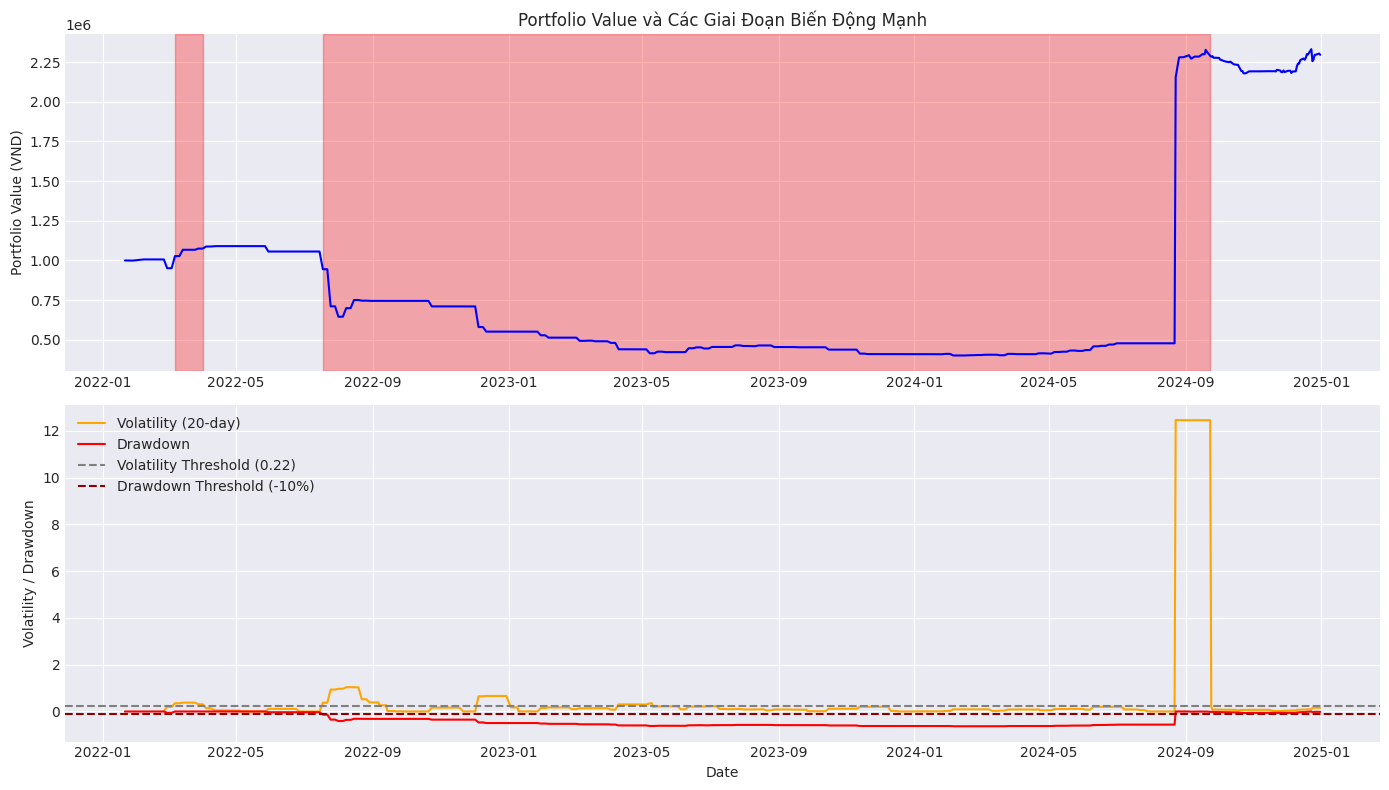

In [35]:
# 6.1 Xác định giai đoạn thị trường biến động mạnh

# Đọc dữ liệu giao dịch và NAV
trades_df = pd.DataFrame(backtester_basic.trades)
nav_df = pd.DataFrame(backtester_basic.daily_portfolio_value)

# Chuyển đổi cột date thành datetime
nav_df['date'] = pd.to_datetime(nav_df['date'])
nav_df = nav_df.sort_values('date')

# Tính toán biến động thị trường
nav_df['daily_return'] = nav_df['portfolio_value'].pct_change()
nav_df['rolling_volatility'] = nav_df['daily_return'].rolling(window=20).std() * np.sqrt(252)  # Annualized

# Xác định các giai đoạn biến động cao
volatility_threshold = nav_df['rolling_volatility'].quantile(0.8)  # Top 20% volatility
nav_df['high_volatility'] = nav_df['rolling_volatility'] > volatility_threshold

# Xác định các giai đoạn drawdown
nav_df['peak'] = nav_df['portfolio_value'].cummax()
nav_df['drawdown'] = (nav_df['portfolio_value'] / nav_df['peak']) - 1.0
nav_df['significant_drawdown'] = nav_df['drawdown'] < -0.1  # Drawdown > 10%

# Kết hợp điều kiện để xác định giai đoạn thị trường biến động mạnh
nav_df['market_stress'] = nav_df['high_volatility'] | nav_df['significant_drawdown']

# Xác định các giai đoạn thị trường biến động mạnh liên tục
stress_periods = []
in_stress = False
start_date = None

for idx, row in nav_df.iterrows():
    if row['market_stress'] and not in_stress:
        in_stress = True
        start_date = row['date']
    elif not row['market_stress'] and in_stress and (idx > 0):
        if (row['date'] - start_date).days >= 5:  # Chỉ quan tâm giai đoạn kéo dài ít nhất 5 ngày
            stress_periods.append({
                'start_date': start_date,
                'end_date': nav_df.iloc[idx-1]['date'],
                'duration_days': (nav_df.iloc[idx-1]['date'] - start_date).days,
                'max_drawdown': nav_df[(nav_df['date'] >= start_date) & 
                                      (nav_df['date'] <= nav_df.iloc[idx-1]['date'])]['drawdown'].min()
            })
        in_stress = False
        start_date = None

# Kiểm tra nếu đang trong giai đoạn stress ở cuối chuỗi dữ liệu
if in_stress and start_date is not None:
    last_date = nav_df.iloc[-1]['date']
    if (last_date - start_date).days >= 5:
        stress_periods.append({
            'start_date': start_date,
            'end_date': last_date,
            'duration_days': (last_date - start_date).days,
            'max_drawdown': nav_df[(nav_df['date'] >= start_date) & 
                                  (nav_df['date'] <= last_date)]['drawdown'].min()
        })

# Hiển thị các giai đoạn thị trường biến động mạnh
print(f"Đã xác định được {len(stress_periods)} giai đoạn thị trường biến động mạnh:")
for i, period in enumerate(stress_periods):
    print(f"{i+1}. {period['start_date'].strftime('%Y-%m-%d')} đến {period['end_date'].strftime('%Y-%m-%d')} "
          f"({period['duration_days']} ngày, Max Drawdown: {period['max_drawdown']*100:.2f}%)")

# Vẽ biểu đồ biến động và drawdown
plt.figure(figsize=(14, 8))

# Subplot 1: Portfolio Value và các giai đoạn biến động
ax1 = plt.subplot(2, 1, 1)
ax1.plot(nav_df['date'], nav_df['portfolio_value'], label='Portfolio Value', color='blue')
ax1.set_title('Portfolio Value và Các Giai Đoạn Biến Động Mạnh')
ax1.set_ylabel('Portfolio Value (VND)')

# Đánh dấu các giai đoạn biến động mạnh
for period in stress_periods:
    ax1.axvspan(period['start_date'], period['end_date'], alpha=0.3, color='red')

# Subplot 2: Volatility và Drawdown
ax2 = plt.subplot(2, 1, 2, sharex=ax1)
ax2.plot(nav_df['date'], nav_df['rolling_volatility'], label='Volatility (20-day)', color='orange')
ax2.plot(nav_df['date'], nav_df['drawdown'], label='Drawdown', color='red')
ax2.axhline(y=volatility_threshold, color='gray', linestyle='--', label=f'Volatility Threshold ({volatility_threshold:.2f})')
ax2.axhline(y=-0.1, color='darkred', linestyle='--', label='Drawdown Threshold (-10%)')
ax2.set_ylabel('Volatility / Drawdown')
ax2.set_xlabel('Date')
ax2.legend()

plt.tight_layout()
plt.show()

# Lưu các giai đoạn biến động mạnh để phân tích tiếp theo
market_stress_periods = stress_periods


In [36]:
# 6.2 Phân tích hiệu suất chiến lược trong giai đoạn biến động mạnh

# Chuyển đổi cột timestamp trong trades_df thành datetime
trades_df['entry_date'] = pd.to_datetime(trades_df['entry_date'])
trades_df['exit_date'] = pd.to_datetime(trades_df['exit_date'])

# Hàm kiểm tra xem một giao dịch có nằm trong giai đoạn biến động mạnh không
def is_trade_in_stress_period(trade, stress_periods):
    for period in stress_periods:
        # Giao dịch mở trong giai đoạn stress
        if (trade['entry_date'] >= period['start_date'] and trade['entry_date'] <= period['end_date']):
            return True
        # Giao dịch đóng trong giai đoạn stress
        if (trade['exit_date'] >= period['start_date'] and trade['exit_date'] <= period['end_date']):
            return True
        # Giao dịch bắt đầu trước và kết thúc sau giai đoạn stress (bao trùm)
        if (trade['entry_date'] <= period['start_date'] and trade['exit_date'] >= period['end_date']):
            return True
    return False

# Phân loại các giao dịch
trades_df['in_stress_period'] = trades_df.apply(lambda x: is_trade_in_stress_period(x, market_stress_periods), axis=1)

# Phân tích hiệu suất trong và ngoài giai đoạn biến động
stress_trades = trades_df[trades_df['in_stress_period']]
normal_trades = trades_df[~trades_df['in_stress_period']]

# Tính toán các chỉ số hiệu suất
def calculate_performance_metrics(trades):
    if len(trades) == 0:
        return {
            'total_trades': 0,
            'winning_trades': 0,
            'losing_trades': 0,
            'win_rate': 0,
            'avg_win': 0,
            'avg_loss': 0,
            'avg_return': 0,
            'profit_factor': 0,
            'max_drawdown': 0
        }
    
    winning_trades = trades[trades['trade_return'] > 0]
    losing_trades = trades[trades['trade_return'] < 0]
    
    metrics = {
        'total_trades': len(trades),
        'winning_trades': len(winning_trades),
        'losing_trades': len(losing_trades),
        'win_rate': len(winning_trades) / len(trades) if len(trades) > 0 else 0,
        'avg_win': winning_trades['trade_return_pct'].mean() if len(winning_trades) > 0 else 0,
        'avg_loss': losing_trades['trade_return_pct'].mean() if len(losing_trades) > 0 else 0,
        'avg_return': trades['trade_return_pct'].mean(),
        'profit_factor': abs(winning_trades['trade_return'].sum() / losing_trades['trade_return'].sum()) if len(losing_trades) > 0 and losing_trades['trade_return'].sum() != 0 else float('inf'),
        'best_trade': trades['trade_return_pct'].max() if len(trades) > 0 else 0,
        'worst_trade': trades['trade_return_pct'].min() if len(trades) > 0 else 0
    }
    
    return metrics

# Tính toán chỉ số hiệu suất cho các giai đoạn
stress_metrics = calculate_performance_metrics(stress_trades)
normal_metrics = calculate_performance_metrics(normal_trades)
overall_metrics = calculate_performance_metrics(trades_df)

# Hiển thị kết quả phân tích
print("\n" + "="*60)
print("PHÂN TÍCH HIỆU SUẤT TRONG GIAI ĐOẠN BIẾN ĐỘNG MẠNH")
print("="*60)

print(f"\n1. TỔNG QUAN:")
print(f"   - Tổng số giao dịch: {overall_metrics['total_trades']}")
print(f"   - Giao dịch trong giai đoạn biến động: {stress_metrics['total_trades']} ({stress_metrics['total_trades']/overall_metrics['total_trades']*100:.1f}%)")
print(f"   - Giao dịch trong giai đoạn bình thường: {normal_metrics['total_trades']} ({normal_metrics['total_trades']/overall_metrics['total_trades']*100:.1f}%)")

print(f"\n2. HIỆU SUẤT GIAI ĐOẠN BIẾN ĐỘNG:")
print(f"   - Tỷ lệ thắng: {stress_metrics['win_rate']*100:.2f}%")
print(f"   - Lợi nhuận TB/giao dịch: {stress_metrics['avg_return']*100:.2f}%")
print(f"   - Profit Factor: {stress_metrics['profit_factor']:.2f}")
print(f"   - Giao dịch tốt nhất: {stress_metrics['best_trade']*100:.2f}%")
print(f"   - Giao dịch tệ nhất: {stress_metrics['worst_trade']*100:.2f}%")

print(f"\n3. HIỆU SUẤT GIAI ĐOẠN BÌNH THƯỜNG:")
print(f"   - Tỷ lệ thắng: {normal_metrics['win_rate']*100:.2f}%")
print(f"   - Lợi nhuận TB/giao dịch: {normal_metrics['avg_return']*100:.2f}%")
print(f"   - Profit Factor: {normal_metrics['profit_factor']:.2f}")
print(f"   - Giao dịch tốt nhất: {normal_metrics['best_trade']*100:.2f}%")
print(f"   - Giao dịch tệ nhất: {normal_metrics['worst_trade']*100:.2f}%")

print(f"\n4. SO SÁNH HIỆU SUẤT:")
win_rate_diff = stress_metrics['win_rate'] - normal_metrics['win_rate']
avg_return_diff = stress_metrics['avg_return'] - normal_metrics['avg_return']
print(f"   - Chênh lệch tỷ lệ thắng: {win_rate_diff*100:.2f}% ({'Tốt hơn' if win_rate_diff > 0 else 'Kém hơn'} giai đoạn bình thường)")
print(f"   - Chênh lệch lợi nhuận TB: {avg_return_diff*100:.2f}% ({'Tốt hơn' if avg_return_diff > 0 else 'Kém hơn'} giai đoạn bình thường)")

# Lưu kết quả phân tích để sử dụng tiếp
performance_analysis = {
    'stress_metrics': stress_metrics,
    'normal_metrics': normal_metrics,
    'overall_metrics': overall_metrics
}



PHÂN TÍCH HIỆU SUẤT TRONG GIAI ĐOẠN BIẾN ĐỘNG MẠNH

1. TỔNG QUAN:
   - Tổng số giao dịch: 149
   - Giao dịch trong giai đoạn biến động: 113 (75.8%)
   - Giao dịch trong giai đoạn bình thường: 36 (24.2%)

2. HIỆU SUẤT GIAI ĐOẠN BIẾN ĐỘNG:
   - Tỷ lệ thắng: 38.94%
   - Lợi nhuận TB/giao dịch: 114.34%
   - Profit Factor: 1.20
   - Giao dịch tốt nhất: 13264.87%
   - Giao dịch tệ nhất: -59.73%

3. HIỆU SUẤT GIAI ĐOẠN BÌNH THƯỜNG:
   - Tỷ lệ thắng: 36.11%
   - Lợi nhuận TB/giao dịch: 1.73%
   - Profit Factor: 0.64
   - Giao dịch tốt nhất: 26.89%
   - Giao dịch tệ nhất: -14.59%

4. SO SÁNH HIỆU SUẤT:
   - Chênh lệch tỷ lệ thắng: 2.83% (Tốt hơn giai đoạn bình thường)
   - Chênh lệch lợi nhuận TB: 112.61% (Tốt hơn giai đoạn bình thường)


In [37]:
# 6.3 Phân tích tín hiệu giao dịch trong giai đoạn biến động mạnh

# Trích xuất các tín hiệu giao dịch từ dữ liệu gốc
# Lấy tất cả các giao dịch trong giai đoạn biến động
stress_trade_tickers = set(stress_trades['ticker'])
stress_trade_dates = []
for _, trade in stress_trades.iterrows():
    # Lấy khoảng thời gian từ entry đến exit
    trade_period = pd.date_range(start=trade['entry_date'], end=trade['exit_date'])
    stress_trade_dates.extend([(trade['ticker'], date) for date in trade_period])

stress_trade_dates = set(stress_trade_dates)

# Phân tích tín hiệu mua/bán trong giai đoạn biến động
df_signals_copy = df_with_signals.copy()
df_signals_copy['timestamp'] = pd.to_datetime(df_signals_copy['timestamp'])

# Xác định các tín hiệu trong giai đoạn biến động
def is_in_stress_period(row, stress_periods):
    date = row['timestamp']
    for period in stress_periods:
        if date >= period['start_date'] and date <= period['end_date']:
            return True
    return False

df_signals_copy['in_stress_period'] = df_signals_copy.apply(lambda x: is_in_stress_period(x, market_stress_periods), axis=1)

# Lọc tín hiệu mua trong giai đoạn biến động
stress_buy_signals = df_signals_copy[(df_signals_copy['in_stress_period']) & (df_signals_copy['multi_strategy_entry'] == 1)]
normal_buy_signals = df_signals_copy[(~df_signals_copy['in_stress_period']) & (df_signals_copy['multi_strategy_entry'] == 1)]

# Lọc tín hiệu bán trong giai đoạn biến động
stress_sell_signals = df_signals_copy[(df_signals_copy['in_stress_period']) & (df_signals_copy['basic_long_exit'] == 1)]
normal_sell_signals = df_signals_copy[(~df_signals_copy['in_stress_period']) & (df_signals_copy['basic_long_exit'] == 1)]

# Tính toán tỷ lệ tín hiệu sai
# Định nghĩa tín hiệu sai: tín hiệu mua dẫn đến lỗ hoặc tín hiệu bán dẫn đến bỏ lỡ lợi nhuận
# Để đơn giản, chúng ta sẽ xem xét các giao dịch lỗ là tín hiệu mua sai

# Tỷ lệ tín hiệu mua sai trong giai đoạn biến động
stress_false_buys = stress_trades[stress_trades['trade_return'] < 0]
normal_false_buys = normal_trades[normal_trades['trade_return'] < 0]

stress_false_buy_rate = len(stress_false_buys) / len(stress_trades) if len(stress_trades) > 0 else 0
normal_false_buy_rate = len(normal_false_buys) / len(normal_trades) if len(normal_trades) > 0 else 0

# Phân tích độ lớn của thua lỗ trong giai đoạn biến động
avg_stress_loss = stress_false_buys['trade_return_pct'].mean() if len(stress_false_buys) > 0 else 0
avg_normal_loss = normal_false_buys['trade_return_pct'].mean() if len(normal_false_buys) > 0 else 0

# Phân tích thời gian nắm giữ các giao dịch lỗ
avg_stress_holding_days = stress_false_buys['holding_days'].mean() if len(stress_false_buys) > 0 else 0
avg_normal_holding_days = normal_false_buys['holding_days'].mean() if len(normal_false_buys) > 0 else 0

# Hiển thị kết quả phân tích
print("\n" + "="*60)
print("PHÂN TÍCH TÍN HIỆU GIAO DỊCH TRONG GIAI ĐOẠN BIẾN ĐỘNG MẠNH")
print("="*60)

print(f"\n1. TỔNG QUAN TÍN HIỆU:")
print(f"   - Tổng số tín hiệu mua trong giai đoạn biến động: {len(stress_buy_signals)}")
print(f"   - Tổng số tín hiệu mua trong giai đoạn bình thường: {len(normal_buy_signals)}")
print(f"   - Tỷ lệ tín hiệu mua trong giai đoạn biến động: {len(stress_buy_signals)/(len(stress_buy_signals)+len(normal_buy_signals))*100:.2f}%")

print(f"\n2. PHÂN TÍCH TÍN HIỆU SAI:")
print(f"   - Tỷ lệ tín hiệu mua sai trong giai đoạn biến động: {stress_false_buy_rate*100:.2f}%")
print(f"   - Tỷ lệ tín hiệu mua sai trong giai đoạn bình thường: {normal_false_buy_rate*100:.2f}%")
print(f"   - Chênh lệch tỷ lệ tín hiệu sai: {(stress_false_buy_rate-normal_false_buy_rate)*100:.2f}%")

print(f"\n3. MỨC ĐỘ TỔN THẤT:")
print(f"   - Tổn thất trung bình/giao dịch lỗ trong giai đoạn biến động: {avg_stress_loss*100:.2f}%")
print(f"   - Tổn thất trung bình/giao dịch lỗ trong giai đoạn bình thường: {avg_normal_loss*100:.2f}%")
print(f"   - Chênh lệch mức độ tổn thất: {(avg_stress_loss-avg_normal_loss)*100:.2f}%")

print(f"\n4. THỜI GIAN NẮM GIỮ:")
print(f"   - Thời gian nắm giữ TB các giao dịch lỗ trong giai đoạn biến động: {avg_stress_holding_days:.1f} ngày")
print(f"   - Thời gian nắm giữ TB các giao dịch lỗ trong giai đoạn bình thường: {avg_normal_holding_days:.1f} ngày")


# Phân tích chi tiết các giao dịch lỗ nặng trong giai đoạn biến động
severe_loss_threshold = -0.2  # Lỗ trên 20%
severe_stress_losses = stress_trades[stress_trades['trade_return_pct'] < severe_loss_threshold]

print("\n5. PHÂN TÍCH GIAO DỊCH LỖ NẶNG TRONG GIAI ĐOẠN BIẾN ĐỘNG:")
print(f"   - Số lượng giao dịch lỗ nặng (>{abs(severe_loss_threshold)*100}%): {len(severe_stress_losses)}")
if len(severe_stress_losses) > 0:
    print(f"   - Tỷ lệ giao dịch lỗ nặng: {len(severe_stress_losses)/len(stress_trades)*100:.2f}%")
    print(f"   - Tổn thất trung bình/giao dịch lỗ nặng: {severe_stress_losses['trade_return_pct'].mean()*100:.2f}%")
    print("\n   Top 5 giao dịch lỗ nặng nhất:")
    worst_trades = severe_stress_losses.sort_values('trade_return_pct').head(5)
    for i, (_, trade) in enumerate(worst_trades.iterrows()):
        print(f"   {i+1}. Mã: {trade['ticker']}, Ngày vào: {trade['entry_date'].strftime('%Y-%m-%d')}, "
              f"Ngày ra: {trade['exit_date'].strftime('%Y-%m-%d')}, "
              f"Lỗ: {trade['trade_return_pct']*100:.2f}%, Lý do: {trade['exit_reason']}")

# Lưu kết quả phân tích để sử dụng tiếp
signal_analysis = {
    'stress_false_buy_rate': stress_false_buy_rate,
    'normal_false_buy_rate': normal_false_buy_rate,
    'avg_stress_loss': avg_stress_loss,
    'avg_normal_loss': avg_normal_loss,
    'severe_stress_losses': severe_stress_losses
}



PHÂN TÍCH TÍN HIỆU GIAO DỊCH TRONG GIAI ĐOẠN BIẾN ĐỘNG MẠNH

1. TỔNG QUAN TÍN HIỆU:
   - Tổng số tín hiệu mua trong giai đoạn biến động: 245988
   - Tổng số tín hiệu mua trong giai đoạn bình thường: 62513
   - Tỷ lệ tín hiệu mua trong giai đoạn biến động: 79.74%

2. PHÂN TÍCH TÍN HIỆU SAI:
   - Tỷ lệ tín hiệu mua sai trong giai đoạn biến động: 61.06%
   - Tỷ lệ tín hiệu mua sai trong giai đoạn bình thường: 63.89%
   - Chênh lệch tỷ lệ tín hiệu sai: -2.83%

3. MỨC ĐỘ TỔN THẤT:
   - Tổn thất trung bình/giao dịch lỗ trong giai đoạn biến động: -12.86%
   - Tổn thất trung bình/giao dịch lỗ trong giai đoạn bình thường: -1.91%
   - Chênh lệch mức độ tổn thất: -10.95%

4. THỜI GIAN NẮM GIỮ:
   - Thời gian nắm giữ TB các giao dịch lỗ trong giai đoạn biến động: 50.8 ngày
   - Thời gian nắm giữ TB các giao dịch lỗ trong giai đoạn bình thường: 16.7 ngày

5. PHÂN TÍCH GIAO DỊCH LỖ NẶNG TRONG GIAI ĐOẠN BIẾN ĐỘNG:
   - Số lượng giao dịch lỗ nặng (>20.0%): 17
   - Tỷ lệ giao dịch lỗ nặng: 15.04%
   -